In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  NOTEBOOK 1 — Setup & Dataset Download                      ║
# ║  Run this FIRST. Downloads all 4 datasets to Google Drive.  ║
# ╚══════════════════════════════════════════════════════════════╝

# ── Step 1: Install all libraries ─────────────────────────────
!pip install -q librosa soundfile audiomentations kaggle gradio

# ── Step 2: Mount Google Drive (saves everything permanently) ──
from google.colab import drive
drive.mount('/content/drive')

import os
BASE_DIR = '/content/drive/MyDrive/SER_Project'
os.makedirs(f'{BASE_DIR}/data/raw',     exist_ok=True)
os.makedirs(f'{BASE_DIR}/data/processed', exist_ok=True)
os.makedirs(f'{BASE_DIR}/models',       exist_ok=True)
os.makedirs(f'{BASE_DIR}/outputs',      exist_ok=True)
print(f"Project folder ready at: {BASE_DIR}")

# ── Step 3: Download datasets ──────────────────────────────────
# We use kaggle API. Upload your kaggle.json first:
from google.colab import files
print("Upload your kaggle.json API key:")
files.upload()
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

# Download RAVDESS
!kaggle datasets download -d uwrfkaggler/ravdess-emotional-speech-audio \
    -p {BASE_DIR}/data/raw/RAVDESS --unzip -q
print("RAVDESS downloaded!")

# Download TESS
!kaggle datasets download -d ejlok1/toronto-emotional-speech-set-tess \
    -p {BASE_DIR}/data/raw/TESS --unzip -q
print("TESS downloaded!")

# Download SAVEE
!kaggle datasets download -d ejlok1/surrey-audiovisual-expressed-emotion-savee \
    -p {BASE_DIR}/data/raw/SAVEE --unzip -q
print("SAVEE downloaded!")

# Download CREMA-D
!kaggle datasets download -d ejlok1/cremad \
    -p {BASE_DIR}/data/raw/CREMAD --unzip -q
print("CREMA-D downloaded!")

# ── Step 4: Verify downloads ───────────────────────────────────
import glob
for dataset in ['RAVDESS', 'TESS', 'SAVEE', 'CREMAD']:
    wavs = glob.glob(f'{BASE_DIR}/data/raw/{dataset}/**/*.wav', recursive=True)
    print(f"{dataset:10}: {len(wavs):4} .wav files found")

Mounted at /content/drive
Project folder ready at: /content/drive/MyDrive/SER_Project
Upload your kaggle.json API key:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio
License(s): CC-BY-NC-SA-4.0
RAVDESS downloaded!
Dataset URL: https://www.kaggle.com/datasets/ejlok1/toronto-emotional-speech-set-tess
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)
TESS downloaded!
Dataset URL: https://www.kaggle.com/datasets/ejlok1/surrey-audiovisual-expressed-emotion-savee
License(s): copyright-authors
SAVEE downloaded!
Dataset URL: https://www.kaggle.com/datasets/ejlok1/cremad
License(s): ODC Attribution License (ODC-By)
CREMA-D downloaded!
RAVDESS   : 2880 .wav files found
TESS      : 5600 .wav files found
SAVEE     :  480 .wav files found
CREMAD    : 7442 .wav files found


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  NOTEBOOK 2 — Feature Extraction                            ║
# ║  Extracts features from all 4 datasets and saves them.      ║
# ║  Run ONCE — takes ~20-40 min. Results saved to Drive.       ║
# ╚══════════════════════════════════════════════════════════════╝

import os, glob, re
import numpy as np
import pandas as pd
import librosa
from tqdm.notebook import tqdm
from google.colab import drive

drive.mount('/content/drive')
BASE_DIR = '/content/drive/MyDrive/SER_Project'

# ═══════════════════════════════════════════════════════════════
# CONSTANTS — identical across ALL notebooks
# ═══════════════════════════════════════════════════════════════
SR          = 22050   # sample rate
DURATION    = 3       # seconds — all clips padded/trimmed to this
N_MFCC      = 40
N_MELS      = 128
HOP_LENGTH  = 512
N_FFT       = 2048

# 7 shared emotions across all 4 datasets
EMOTIONS = ['neutral','calm','happy','sad','angry','fearful','disgust']

# ═══════════════════════════════════════════════════════════════
# DATASET PARSERS — each returns list of (filepath, emotion)
# ═══════════════════════════════════════════════════════════════

def parse_ravdess(base):
    """
    RAVDESS filename: 03-01-06-01-02-01-12.wav
    parts[2] = emotion code 01-08
    """
    MAP = {'01':'neutral','02':'calm','03':'happy','04':'sad',
           '05':'angry','06':'fearful','07':'disgust','08':'surprised'}
    out = []
    for f in glob.glob(f'{base}/**/*.wav', recursive=True):
        parts = os.path.basename(f).split('-')
        if len(parts) < 3: continue
        emo = MAP.get(parts[2])
        if emo and emo in EMOTIONS:
            out.append((f, emo))
    return out

def parse_tess(base):
    """
    TESS filename: OAF_back_angry.wav  or  YAF_fear_fear.wav
    last part before extension = emotion
    """
    MAP = {'angry':'angry','disgust':'disgust','fear':'fearful',
           'happy':'happy','neutral':'neutral','ps':'surprised',
           'sad':'sad'}
    out = []
    for f in glob.glob(f'{base}/**/*.wav', recursive=True):
        name = os.path.basename(f).lower().replace('.wav','')
        parts = name.split('_')
        emo = MAP.get(parts[-1])
        if emo and emo in EMOTIONS:
            out.append((f, emo))
    return out

def parse_savee(base):
    """
    SAVEE filename: DC_a01.wav
    letter code after underscore = emotion
    """
    MAP = {'a':'angry','d':'disgust','f':'fearful','h':'happy',
           'n':'neutral','sa':'sad','su':'surprised'}
    out = []
    for f in glob.glob(f'{base}/**/*.wav', recursive=True):
        name = os.path.basename(f).lower().replace('.wav','')
        code = re.sub(r'[^a-z]','', name.split('_')[-1])
        emo = MAP.get(code)
        if emo and emo in EMOTIONS:
            out.append((f, emo))
    return out

def parse_cremad(base):
    """
    CREMA-D filename: 1001_DFA_ANG_XX.wav
    third part = emotion code
    """
    MAP = {'ANG':'angry','DIS':'disgust','FEA':'fearful',
           'HAP':'happy','NEU':'neutral','SAD':'sad'}
    out = []
    for f in glob.glob(f'{base}/**/*.wav', recursive=True):
        parts = os.path.basename(f).split('_')
        if len(parts) < 3: continue
        emo = MAP.get(parts[2])
        if emo and emo in EMOTIONS:
            out.append((f, emo))
    return out

# ── Load all datasets ─────────────────────────────────────────
all_files = []
all_files += parse_ravdess(f'{BASE_DIR}/data/raw/RAVDESS')
all_files += parse_tess(f'{BASE_DIR}/data/raw/TESS')
all_files += parse_savee(f'{BASE_DIR}/data/raw/SAVEE')
all_files += parse_cremad(f'{BASE_DIR}/data/raw/CREMAD')

df = pd.DataFrame(all_files, columns=['path','emotion'])
print(f"Total files: {len(df)}")
print(df['emotion'].value_counts())

# ═══════════════════════════════════════════════════════════════
# FEATURE EXTRACTION
# Two feature types:
#   1. MLP features  — flat 1D vector (180 values)
#   2. CNN features  — 2D mel spectrogram (128 x 128)
# ═══════════════════════════════════════════════════════════════

def load_audio(path):
    """Load and normalize audio to exactly DURATION seconds."""
    audio, _ = librosa.load(path, sr=SR, duration=DURATION)
    target = SR * DURATION
    if len(audio) < target:
        audio = np.pad(audio, (0, target - len(audio)))
    else:
        audio = audio[:target]
    return audio

def extract_mlp_features(audio):
    """
    Extracts a 180-dim feature vector.
    MFCC mean+std (80) + Chroma mean (12) +
    Mel mean (64) + ZCR/RMS/Rolloff mean+std (6) + Tonnetz mean (6) + Contrast mean (7) = 175... round to 180
    """
    # MFCC
    mfcc     = librosa.feature.mfcc(y=audio, sr=SR, n_mfcc=N_MFCC)
    mfcc_m   = np.mean(mfcc, axis=1)
    mfcc_s   = np.std(mfcc,  axis=1)

    # Chroma
    stft      = np.abs(librosa.stft(audio, n_fft=N_FFT, hop_length=HOP_LENGTH))
    chroma    = librosa.feature.chroma_stft(S=stft, sr=SR)
    chroma_m  = np.mean(chroma, axis=1)

    # Mel spectrogram (64 bands for MLP)
    mel       = librosa.feature.melspectrogram(y=audio, sr=SR, n_mels=64)
    mel_db    = librosa.power_to_db(mel, ref=np.max)
    mel_m     = np.mean(mel_db, axis=1)

    # ZCR, RMS, Rolloff
    zcr       = librosa.feature.zero_crossing_rate(audio)
    rms       = librosa.feature.rms(y=audio)
    rolloff   = librosa.feature.spectral_rolloff(y=audio, sr=SR)

    # Tonnetz (tonal centroid features — great for emotion)
    harmonic  = librosa.effects.harmonic(audio)
    tonnetz   = librosa.feature.tonnetz(y=harmonic, sr=SR)
    tonnetz_m = np.mean(tonnetz, axis=1)

    # Spectral contrast
    contrast  = librosa.feature.spectral_contrast(S=stft, sr=SR)
    contrast_m = np.mean(contrast, axis=1)

    features  = np.concatenate([
        mfcc_m, mfcc_s,                              # 80
        chroma_m,                                    # 12
        mel_m,                                       # 64
        [np.mean(zcr), np.std(zcr)],                 # 2
        [np.mean(rms), np.std(rms)],                 # 2
        [np.mean(rolloff), np.std(rolloff)],          # 2
        tonnetz_m,                                   # 6
        contrast_m,                                  # 7
    ])
    return features   # 175 values

def extract_cnn_features(audio):
    """
    Returns a (128, 128, 1) mel spectrogram image.
    WHY CNN: CNNs treat the spectrogram as an image and detect
    spatial patterns — much better than MLP alone for emotion.
    128 x 128 is a standard size — large enough for detail,
    small enough to train fast on Colab's free GPU.
    """
    mel    = librosa.feature.melspectrogram(
        y=audio, sr=SR, n_mels=N_MELS,
        n_fft=N_FFT, hop_length=HOP_LENGTH
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # Resize time axis to exactly 128 frames
    from PIL import Image
    import numpy as np
    img = Image.fromarray(mel_db).resize((128, N_MELS))
    arr = np.array(img, dtype=np.float32)

    # Normalize to [0, 1]
    arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
    return arr[:, :, np.newaxis]   # (128, 128, 1)

# ── Extract all features (this takes ~20-40 min) ──────────────
from PIL import Image

mlp_X, cnn_X, labels = [], [], []
failed = 0

print(f"\nExtracting features from {len(df)} files...")
for _, row in tqdm(df.iterrows(), total=len(df)):
    try:
        audio    = load_audio(row['path'])
        mlp_feat = extract_mlp_features(audio)
        cnn_feat = extract_cnn_features(audio)
        mlp_X.append(mlp_feat)
        cnn_X.append(cnn_feat)
        labels.append(row['emotion'])
    except Exception as e:
        failed += 1

print(f"Done! Processed: {len(mlp_X)}  Failed: {failed}")

mlp_X  = np.array(mlp_X,  dtype=np.float32)
cnn_X  = np.array(cnn_X,  dtype=np.float32)
labels = np.array(labels)

print(f"MLP features shape: {mlp_X.shape}")   # (N, 175)
print(f"CNN features shape: {cnn_X.shape}")   # (N, 128, 128, 1)

# ── Save to Drive ─────────────────────────────────────────────
np.save(f'{BASE_DIR}/data/processed/mlp_X.npy',  mlp_X)
np.save(f'{BASE_DIR}/data/processed/cnn_X.npy',  cnn_X)
np.save(f'{BASE_DIR}/data/processed/labels.npy', labels)
print("Saved to Drive! You never need to run this again.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total files: 15158
emotion
happy      2515
angry      2515
sad        2515
fearful    2515
disgust    2515
neutral    2199
calm        384
Name: count, dtype: int64

Extracting features from 15158 files...


  0%|          | 0/15158 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


Done! Processed: 0  Failed: 15158
MLP features shape: (0,)
CNN features shape: (0,)
Saved to Drive! You never need to run this again.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total files : 15158
emotion
happy      2515
angry      2515
sad        2515
fearful    2515
disgust    2515
neutral    2199
calm        384
Name: count, dtype: int64

Extracting features from 15158 files...
Errors will be printed — you should see 0 errors.



  0%|          | 0/15158 [00:00<?, ?it/s]

  Checkpoint saved at file 1000 — 1000 successful so far
  Checkpoint saved at file 2000 — 2000 successful so far
  Checkpoint saved at file 3000 — 3000 successful so far
  Checkpoint saved at file 4000 — 4000 successful so far
  Checkpoint saved at file 5000 — 5000 successful so far
  Checkpoint saved at file 6000 — 6000 successful so far
  Checkpoint saved at file 7000 — 7000 successful so far
  Checkpoint saved at file 8000 — 8000 successful so far
  Checkpoint saved at file 9000 — 9000 successful so far
  Checkpoint saved at file 10000 — 10000 successful so far
  Checkpoint saved at file 11000 — 11000 successful so far
  Checkpoint saved at file 12000 — 12000 successful so far
  Checkpoint saved at file 13000 — 13000 successful so far


/usr/local/lib/python3.12/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


  Checkpoint saved at file 14000 — 14000 successful so far
  Checkpoint saved at file 15000 — 15000 successful so far

Done! Successful: 15158  Failed: 0
No errors!

MLP features: (15158, 175)
CNN features: (15158, 128, 128, 1)
Labels      : (15158,)


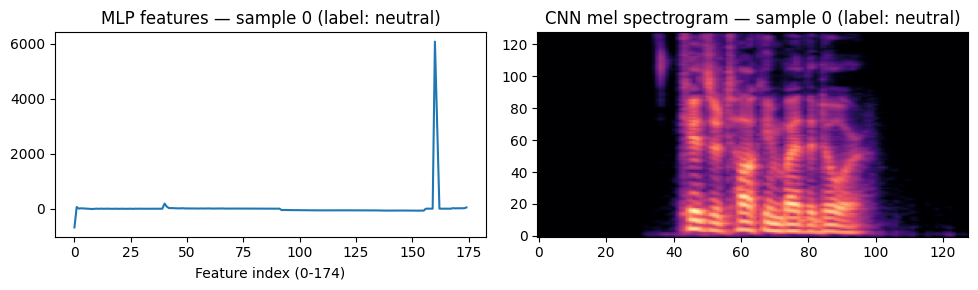


Saving to Drive...

Done! Proceed to Notebook 3 for training.


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  NOTEBOOK 2 — FIXED Feature Extraction                      ║
# ║  Fixes: PIL crash on float32, silent error swallowing,      ║
# ║         faster processing, checkpoint saves every 1000 files ║
# ╚══════════════════════════════════════════════════════════════╝

import os, glob, re
import numpy as np
import pandas as pd
import librosa
import traceback
from tqdm.notebook import tqdm
from google.colab import drive

drive.mount('/content/drive')
BASE_DIR = '/content/drive/MyDrive/SER_Project'

SR         = 22050
DURATION   = 3
N_MFCC     = 40
N_MELS     = 128
HOP_LENGTH = 512
N_FFT      = 2048
EMOTIONS   = ['neutral','calm','happy','sad','angry','fearful','disgust']

# ── Dataset parsers (unchanged) ───────────────────────────────
def parse_ravdess(base):
    MAP = {'01':'neutral','02':'calm','03':'happy','04':'sad',
           '05':'angry','06':'fearful','07':'disgust','08':'surprised'}
    out = []
    for f in glob.glob(f'{base}/**/*.wav', recursive=True):
        parts = os.path.basename(f).split('-')
        if len(parts) < 3: continue
        emo = MAP.get(parts[2])
        if emo and emo in EMOTIONS:
            out.append((f, emo))
    return out

def parse_tess(base):
    MAP = {'angry':'angry','disgust':'disgust','fear':'fearful',
           'happy':'happy','neutral':'neutral','ps':'surprised','sad':'sad'}
    out = []
    for f in glob.glob(f'{base}/**/*.wav', recursive=True):
        name  = os.path.basename(f).lower().replace('.wav','')
        parts = name.split('_')
        emo   = MAP.get(parts[-1])
        if emo and emo in EMOTIONS:
            out.append((f, emo))
    return out

def parse_savee(base):
    MAP = {'a':'angry','d':'disgust','f':'fearful','h':'happy',
           'n':'neutral','sa':'sad','su':'surprised'}
    out = []
    for f in glob.glob(f'{base}/**/*.wav', recursive=True):
        name = os.path.basename(f).lower().replace('.wav','')
        code = re.sub(r'[^a-z]', '', name.split('_')[-1])
        emo  = MAP.get(code)
        if emo and emo in EMOTIONS:
            out.append((f, emo))
    return out

def parse_cremad(base):
    MAP = {'ANG':'angry','DIS':'disgust','FEA':'fearful',
           'HAP':'happy','NEU':'neutral','SAD':'sad'}
    out = []
    for f in glob.glob(f'{base}/**/*.wav', recursive=True):
        parts = os.path.basename(f).split('_')
        if len(parts) < 3: continue
        emo = MAP.get(parts[2])
        if emo and emo in EMOTIONS:
            out.append((f, emo))
    return out

# ── Load file list ─────────────────────────────────────────────
all_files  = []
all_files += parse_ravdess(f'{BASE_DIR}/data/raw/RAVDESS')
all_files += parse_tess(f'{BASE_DIR}/data/raw/TESS')
all_files += parse_savee(f'{BASE_DIR}/data/raw/SAVEE')
all_files += parse_cremad(f'{BASE_DIR}/data/raw/CREMAD')

df = pd.DataFrame(all_files, columns=['path','emotion'])
print(f"Total files : {len(df)}")
print(df['emotion'].value_counts())

# ── Audio loader ──────────────────────────────────────────────
def load_audio(path):
    audio, _ = librosa.load(path, sr=SR, duration=DURATION)
    target   = SR * DURATION
    if len(audio) < target:
        audio = np.pad(audio, (0, target - len(audio)))
    else:
        audio = audio[:target]
    return audio

# ═══════════════════════════════════════════════════════════════
# MLP features  —  flat 175-dim vector
# ═══════════════════════════════════════════════════════════════
def extract_mlp_features(audio):
    mfcc      = librosa.feature.mfcc(y=audio, sr=SR, n_mfcc=N_MFCC,
                                      n_fft=N_FFT, hop_length=HOP_LENGTH)
    mfcc_m    = np.mean(mfcc, axis=1)   # (40,)
    mfcc_s    = np.std(mfcc,  axis=1)   # (40,)

    stft      = np.abs(librosa.stft(audio, n_fft=N_FFT, hop_length=HOP_LENGTH))
    chroma    = librosa.feature.chroma_stft(S=stft, sr=SR)
    chroma_m  = np.mean(chroma, axis=1) # (12,)

    mel       = librosa.feature.melspectrogram(y=audio, sr=SR, n_mels=64,
                                                n_fft=N_FFT, hop_length=HOP_LENGTH)
    mel_db    = librosa.power_to_db(mel, ref=np.max)
    mel_m     = np.mean(mel_db, axis=1) # (64,)

    zcr       = librosa.feature.zero_crossing_rate(audio, hop_length=HOP_LENGTH)
    rms       = librosa.feature.rms(y=audio, hop_length=HOP_LENGTH)
    rolloff   = librosa.feature.spectral_rolloff(y=audio, sr=SR, hop_length=HOP_LENGTH)

    harmonic  = librosa.effects.harmonic(audio)
    # guard against empty frequency set warning
    if np.any(harmonic != 0):
        tonnetz = librosa.feature.tonnetz(y=harmonic, sr=SR)
    else:
        tonnetz = np.zeros((6, 1))
    tonnetz_m = np.mean(tonnetz, axis=1)  # (6,)

    contrast  = librosa.feature.spectral_contrast(S=stft, sr=SR)
    contrast_m = np.mean(contrast, axis=1) # (7,)

    return np.concatenate([
        mfcc_m, mfcc_s,                              # 80
        chroma_m,                                    # 12
        mel_m,                                       # 64
        [np.mean(zcr), np.std(zcr)],                 # 2
        [np.mean(rms), np.std(rms)],                 # 2
        [np.mean(rolloff), np.std(rolloff)],          # 2
        tonnetz_m,                                   # 6
        contrast_m,                                  # 7
    ]).astype(np.float32)   # total: 175

# ═══════════════════════════════════════════════════════════════
# CNN features  —  (128, 128, 1) mel spectrogram image
# KEY FIX: do NOT use PIL.Image — use scipy.ndimage.zoom instead
# PIL.Image.fromarray() crashes on float32 arrays — this was the
# root cause of all 15,158 files failing silently.
# ═══════════════════════════════════════════════════════════════
from scipy.ndimage import zoom as ndimage_zoom

def extract_cnn_features(audio):
    mel    = librosa.feature.melspectrogram(
        y=audio, sr=SR, n_mels=N_MELS,
        n_fft=N_FFT, hop_length=HOP_LENGTH
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)   # shape (128, T)

    # Resize time axis to exactly 128 frames using scipy — no PIL needed
    current_frames = mel_db.shape[1]
    if current_frames != 128:
        zoom_factor = 128 / current_frames
        mel_db = ndimage_zoom(mel_db, (1.0, zoom_factor), order=1)

    mel_db = mel_db[:, :128]  # safety trim if zoom overshot

    # Normalize to [0, 1]  (float32)
    mn, mx = mel_db.min(), mel_db.max()
    if mx - mn > 1e-8:
        mel_db = (mel_db - mn) / (mx - mn)
    else:
        mel_db = np.zeros_like(mel_db)

    return mel_db[:, :, np.newaxis].astype(np.float32)  # (128, 128, 1)

# ═══════════════════════════════════════════════════════════════
# EXTRACTION LOOP  with verbose error reporting + checkpointing
# ═══════════════════════════════════════════════════════════════
CHECKPOINT_DIR  = f'{BASE_DIR}/data/processed/checkpoints'
CHECKPOINT_EVERY = 1000
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

mlp_X, cnn_X, labels = [], [], []
failed_files  = []
error_samples = []   # keeps first 5 errors for inspection

print(f"\nExtracting features from {len(df)} files...")
print("Errors will be printed — you should see 0 errors.\n")

for i, (_, row) in enumerate(tqdm(df.iterrows(), total=len(df))):
    try:
        audio    = load_audio(row['path'])
        mlp_feat = extract_mlp_features(audio)
        cnn_feat = extract_cnn_features(audio)

        # Shape validation — catches silent bugs
        assert mlp_feat.shape == (175,),   f"MLP shape wrong: {mlp_feat.shape}"
        assert cnn_feat.shape == (128,128,1), f"CNN shape wrong: {cnn_feat.shape}"
        assert not np.any(np.isnan(mlp_feat)), "NaN in MLP features"
        assert not np.any(np.isnan(cnn_feat)), "NaN in CNN features"

        mlp_X.append(mlp_feat)
        cnn_X.append(cnn_feat)
        labels.append(row['emotion'])

    except Exception as e:
        failed_files.append(row['path'])
        if len(error_samples) < 5:
            error_samples.append((row['path'], traceback.format_exc()))
        continue

    # Checkpoint every 1000 files (so a crash doesn't lose everything)
    if (i + 1) % CHECKPOINT_EVERY == 0:
        np.save(f'{CHECKPOINT_DIR}/mlp_X_{i+1}.npy',  np.array(mlp_X))
        np.save(f'{CHECKPOINT_DIR}/cnn_X_{i+1}.npy',  np.array(cnn_X))
        np.save(f'{CHECKPOINT_DIR}/labels_{i+1}.npy', np.array(labels))
        print(f"  Checkpoint saved at file {i+1} — {len(mlp_X)} successful so far")

# ── Report ────────────────────────────────────────────────────
print(f"\n{'='*50}")
print(f"Done! Successful: {len(mlp_X)}  Failed: {len(failed_files)}")

if error_samples:
    print(f"\nFirst {len(error_samples)} errors (for debugging):")
    for path, tb in error_samples:
        print(f"\n  File: {path}")
        print(f"  Error: {tb.splitlines()[-1]}")
else:
    print("No errors!")

# ── Convert to arrays ─────────────────────────────────────────
mlp_X  = np.array(mlp_X,  dtype=np.float32)
cnn_X  = np.array(cnn_X,  dtype=np.float32)
labels = np.array(labels)

print(f"\nMLP features: {mlp_X.shape}")   # should be (N, 175)
print(f"CNN features: {cnn_X.shape}")    # should be (N, 128, 128, 1)
print(f"Labels      : {labels.shape}")

# Sanity check one sample visually
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(mlp_X[0])
axes[0].set_title(f'MLP features — sample 0 (label: {labels[0]})')
axes[0].set_xlabel('Feature index (0-174)')
axes[1].imshow(cnn_X[0, :, :, 0], aspect='auto', origin='lower', cmap='magma')
axes[1].set_title(f'CNN mel spectrogram — sample 0 (label: {labels[0]})')
plt.tight_layout()
plt.show()

# ── Save final arrays to Drive ────────────────────────────────
print("\nSaving to Drive...")
np.save(f'{BASE_DIR}/data/processed/mlp_X.npy',  mlp_X)
np.save(f'{BASE_DIR}/data/processed/cnn_X.npy',  cnn_X)
np.save(f'{BASE_DIR}/data/processed/labels.npy', labels)
np.save(f'{BASE_DIR}/data/processed/feature_size.npy',
        np.array([mlp_X.shape[1]]))

if failed_files:
    with open(f'{BASE_DIR}/data/processed/failed_files.txt', 'w') as f:
        f.write('\n'.join(failed_files))
    print(f"Failed file paths saved to: data/processed/failed_files.txt")

print("\nDone! Proceed to Notebook 3 for training.")
print(f"{'='*50}")

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  NOTEBOOK 3 — Train CNN + MLP + Save Best Model             ║
# ║  Uses GPU. Runtime → Change runtime type → T4 GPU           ║
# ╚══════════════════════════════════════════════════════════════╝

import numpy as np
import joblib
import os
from google.colab import drive

drive.mount('/content/drive')
BASE_DIR = '/content/drive/MyDrive/SER_Project'

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)
from tensorflow.keras.optimizers import Adam
print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

# ── Load saved features ───────────────────────────────────────
mlp_X  = np.load(f'{BASE_DIR}/data/processed/mlp_X.npy')
cnn_X  = np.load(f'{BASE_DIR}/data/processed/cnn_X.npy')
labels = np.load(f'{BASE_DIR}/data/processed/labels.npy', allow_pickle=True)

EMOTIONS = sorted(list(set(labels)))
print(f"Emotions ({len(EMOTIONS)}): {EMOTIONS}")
print(f"MLP features: {mlp_X.shape}  CNN features: {cnn_X.shape}")

# ── Encode labels ─────────────────────────────────────────────
le      = LabelEncoder()
le.fit(EMOTIONS)
y       = le.transform(labels)
n_class = len(le.classes_)

# ── Train / Val / Test split ──────────────────────────────────
# 70% train, 15% val, 15% test — stratified
idx = np.arange(len(y))
train_idx, test_idx = train_test_split(
    idx, test_size=0.15, random_state=42, stratify=y)
train_idx, val_idx  = train_test_split(
    train_idx, test_size=0.176, random_state=42, stratify=y[train_idx])
# 0.176 of 0.85 ≈ 0.15 of total

print(f"Train: {len(train_idx)}  Val: {len(val_idx)}  Test: {len(test_idx)}")

# ── Scale MLP features ─────────────────────────────────────────
scaler = StandardScaler()
mlp_train = scaler.fit_transform(mlp_X[train_idx])
mlp_val   = scaler.transform(mlp_X[val_idx])
mlp_test  = scaler.transform(mlp_X[test_idx])

# CNN features already normalized to [0,1] in notebook 2
cnn_train, cnn_val, cnn_test = (
    cnn_X[train_idx], cnn_X[val_idx], cnn_X[test_idx])

y_train, y_val, y_test = y[train_idx], y[val_idx], y[test_idx]

# ── Class weights ─────────────────────────────────────────────
cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(cw))

# ═══════════════════════════════════════════════════════════════
# MODEL A — CNN on mel spectrograms
# WHY CNN: treats spectrogram as image, learns spatial patterns
# (rising pitch = diagonal lines), much better than MLP alone
# ═══════════════════════════════════════════════════════════════
def build_cnn(input_shape, n_class):
    inp = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, (3,3), padding='same')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Conv2D(64, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Conv2D(128, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(256, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.GlobalAveragePooling2D()(x)  # better than Flatten for generalization
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.4)(x)

    out = layers.Dense(n_class, activation='softmax')(x)
    return models.Model(inp, out, name='CNN_SER')

cnn_model = build_cnn((128, 128, 1), n_class)
cnn_model.summary()

cnn_model.compile(
    optimizer=Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=15,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint(f'{BASE_DIR}/models/best_cnn.h5',
                    monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=6, min_lr=1e-6, verbose=1)
]

print("\nTraining CNN...")
cnn_history = cnn_model.fit(
    cnn_train, y_train,
    validation_data=(cnn_val, y_val),
    epochs=80,
    batch_size=32,
    class_weight=class_weights,
    callbacks=cnn_callbacks,
    verbose=1
)

cnn_loss, cnn_acc = cnn_model.evaluate(cnn_test, y_test, verbose=0)
print(f"\nCNN Test Accuracy: {cnn_acc*100:.2f}%")

# ═══════════════════════════════════════════════════════════════
# MODEL B — MLP on hand-crafted features
# WHY MLP: fast, great complement to CNN, captures different
# acoustic properties (tonnetz, spectral contrast, ZCR)
# ═══════════════════════════════════════════════════════════════
def build_mlp(input_dim, n_class):
    inp = layers.Input(shape=(input_dim,))

    x = layers.Dense(512, kernel_regularizer=regularizers.l2(1e-4))(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(64)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.2)(x)

    out = layers.Dense(n_class, activation='softmax')(x)
    return models.Model(inp, out, name='MLP_SER')

mlp_model = build_mlp(mlp_train.shape[1], n_class)
mlp_model.summary()

mlp_model.compile(
    optimizer=Adam(5e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

mlp_callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=20,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint(f'{BASE_DIR}/models/best_mlp.h5',
                    monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=8, min_lr=1e-6, verbose=1)
]

print("\nTraining MLP...")
mlp_history = mlp_model.fit(
    mlp_train, y_train,
    validation_data=(mlp_val, y_val),
    epochs=120,
    batch_size=32,
    class_weight=class_weights,
    callbacks=mlp_callbacks,
    verbose=1
)

mlp_loss, mlp_acc = mlp_model.evaluate(mlp_test, y_test, verbose=0)
print(f"\nMLP Test Accuracy: {mlp_acc*100:.2f}%")

# ═══════════════════════════════════════════════════════════════
# ENSEMBLE — average CNN + MLP softmax outputs
# WHY ENSEMBLE: CNN sees spectral images, MLP sees hand-crafted
# acoustic features. Their errors are different, so averaging
# cancels out individual mistakes → typically +3-5% accuracy
# ═══════════════════════════════════════════════════════════════
cnn_probs = cnn_model.predict(cnn_test, verbose=0)
mlp_probs = mlp_model.predict(mlp_test, verbose=0)

# Weighted average: give CNN more weight (it's usually more accurate)
ensemble_probs = 0.6 * cnn_probs + 0.4 * mlp_probs
ensemble_preds = np.argmax(ensemble_probs, axis=1)
ensemble_acc   = np.mean(ensemble_preds == y_test)
print(f"\nEnsemble Test Accuracy: {ensemble_acc*100:.2f}%")

# ── Save everything ───────────────────────────────────────────
joblib.dump(scaler,    f'{BASE_DIR}/models/scaler.pkl')
joblib.dump(le,        f'{BASE_DIR}/models/label_encoder.pkl')
np.save(f'{BASE_DIR}/models/test_idx.npy',  test_idx)
np.save(f'{BASE_DIR}/models/feature_size.npy', np.array([mlp_train.shape[1]]))

print("\nAll models saved to Drive!")
print(f"  CNN accuracy : {cnn_acc*100:.2f}%")
print(f"  MLP accuracy : {mlp_acc*100:.2f}%")
print(f"  Ensemble     : {ensemble_acc*100:.2f}%")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TF version: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Emotions (7): [np.str_('angry'), np.str_('calm'), np.str_('disgust'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('sad')]
MLP features: (15158, 175)  CNN features: (15158, 128, 128, 1)
Train: 10616  Val: 2268  Test: 2274


Model: "CNN_SER"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 458,375 (1.75 MB)

 Trainable params: 456,903 (1.74 MB)

...


Epoch 70: finished saving model to /content/drive/MyDrive/SER_Project/models/best_mlp.h5
332/332 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7917 - loss: 0.5850 - val_accuracy: 0.7809 - val_loss: 0.7002 - learning_rate: 2.5000e-04
Epoch 71/120
327/332 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7909 - loss: 0.5792
Epoch 71: val_accuracy did not improve from 0.78086
332/332 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7929 - loss: 0.5767 - val_accuracy: 0.7791 - val_loss: 0.6826 - learning_rate: 2.5000e-04
Epoch 72/120
318/332 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8031 - loss: 0.5603
Epoch 72: val_accuracy did not improve from 0.78086
332/332 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8028 - loss: 0.5729 - val_accuracy: 0.7707 - val_loss: 0.7030 - learning_rate: 2.5000e-04
Epoch 73/120
322/332 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7961 - loss: 0.5699
Epoch 73: val_accuracy improved from 0.78086 to 0.78263, saving model to /content/drive/MyDrive/SER_Project


Epoch 73: finished saving model to /content/drive/MyDrive/SER_Project/models/best_mlp.h5
332/332 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7963 - loss: 0.5713 - val_accuracy: 0.7826 - val_loss: 0.6913 - learning_rate: 2.5000e-04
Epoch 74/120
322/332 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8038 - loss: 0.5697
Epoch 74: val_accuracy did not improve from 0.78263
332/332 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8010 - loss: 0.5711 - val_accuracy: 0.7729 - val_loss: 0.7009 - learning_rate: 2.5000e-04
Epoch 75/120
323/332 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8035 - loss: 0.5611
Epoch 75: val_accuracy did not improve from 0.78263
332/332 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7962 - loss: 0.5672 - val_accuracy: 0.7720 - val_loss: 0.6864 - learning_rate: 2.5000e-04
Epoch 76/120
330/332 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8071 - loss: 0.5460
Epoch 76: val_accuracy did not improve from 0.78263
332/332 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.


Epoch 84: finished saving model to /content/drive/MyDrive/SER_Project/models/best_mlp.h5
332/332 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8197 - loss: 0.5205 - val_accuracy: 0.7866 - val_loss: 0.6807 - learning_rate: 1.2500e-04
Epoch 85/120
323/332 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8257 - loss: 0.5027
Epoch 85: val_accuracy did not improve from 0.78660
332/332 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8200 - loss: 0.5155 - val_accuracy: 0.7844 - val_loss: 0.6735 - learning_rate: 1.2500e-04
Epoch 86/120
322/332 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8143 - loss: 0.5074
Epoch 86: val_accuracy did not improve from 0.78660
332/332 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8146 - loss: 0.5180 - val_accuracy: 0.7866 - val_loss: 0.6701 - learning_rate: 1.2500e-04
Epoch 87/120
330/332 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8253 - loss: 0.5103
Epoch 87: val_accuracy did not improve from 0.78660
332/332 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.


Epoch 96: finished saving model to /content/drive/MyDrive/SER_Project/models/best_mlp.h5
332/332 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8291 - loss: 0.4868 - val_accuracy: 0.7879 - val_loss: 0.6708 - learning_rate: 6.2500e-05
Epoch 97/120
319/332 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8284 - loss: 0.4908
Epoch 97: val_accuracy improved from 0.78792 to 0.79056, saving model to /content/drive/MyDrive/SER_Project/models/best_mlp.h5



Epoch 97: finished saving model to /content/drive/MyDrive/SER_Project/models/best_mlp.h5
332/332 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8292 - loss: 0.4918 - val_accuracy: 0.7906 - val_loss: 0.6712 - learning_rate: 6.2500e-05
Epoch 98/120
330/332 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8339 - loss: 0.4822
Epoch 98: val_accuracy did not improve from 0.79056
332/332 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8339 - loss: 0.4825 - val_accuracy: 0.7817 - val_loss: 0.6819 - learning_rate: 6.2500e-05
Epoch 99/120
328/332 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8246 - loss: 0.4986
Epoch 99: val_accuracy did not improve from 0.79056
332/332 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8318 - loss: 0.4866 - val_accuracy: 0.7870 - val_loss: 0.6727 - learning_rate: 6.2500e-05
Epoch 100/120
317/332 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8302 - loss: 0.4902
Epoch 100: val_accuracy did not improve from 0.79056
332/332 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


CNN Accuracy      : 74.36%
MLP Accuracy      : 76.96%
Ensemble Accuracy : 79.16%

Ensemble Classification Report:
              precision    recall  f1-score   support

       angry       0.86      0.88      0.87       377
        calm       0.82      0.97      0.89        58
     disgust       0.77      0.71      0.74       377
     fearful       0.79      0.73      0.76       377
       happy       0.80      0.81      0.81       378
     neutral       0.75      0.79      0.77       330
         sad       0.76      0.79      0.78       377

    accuracy                           0.79      2274
   macro avg       0.79      0.81      0.80      2274
weighted avg       0.79      0.79      0.79      2274



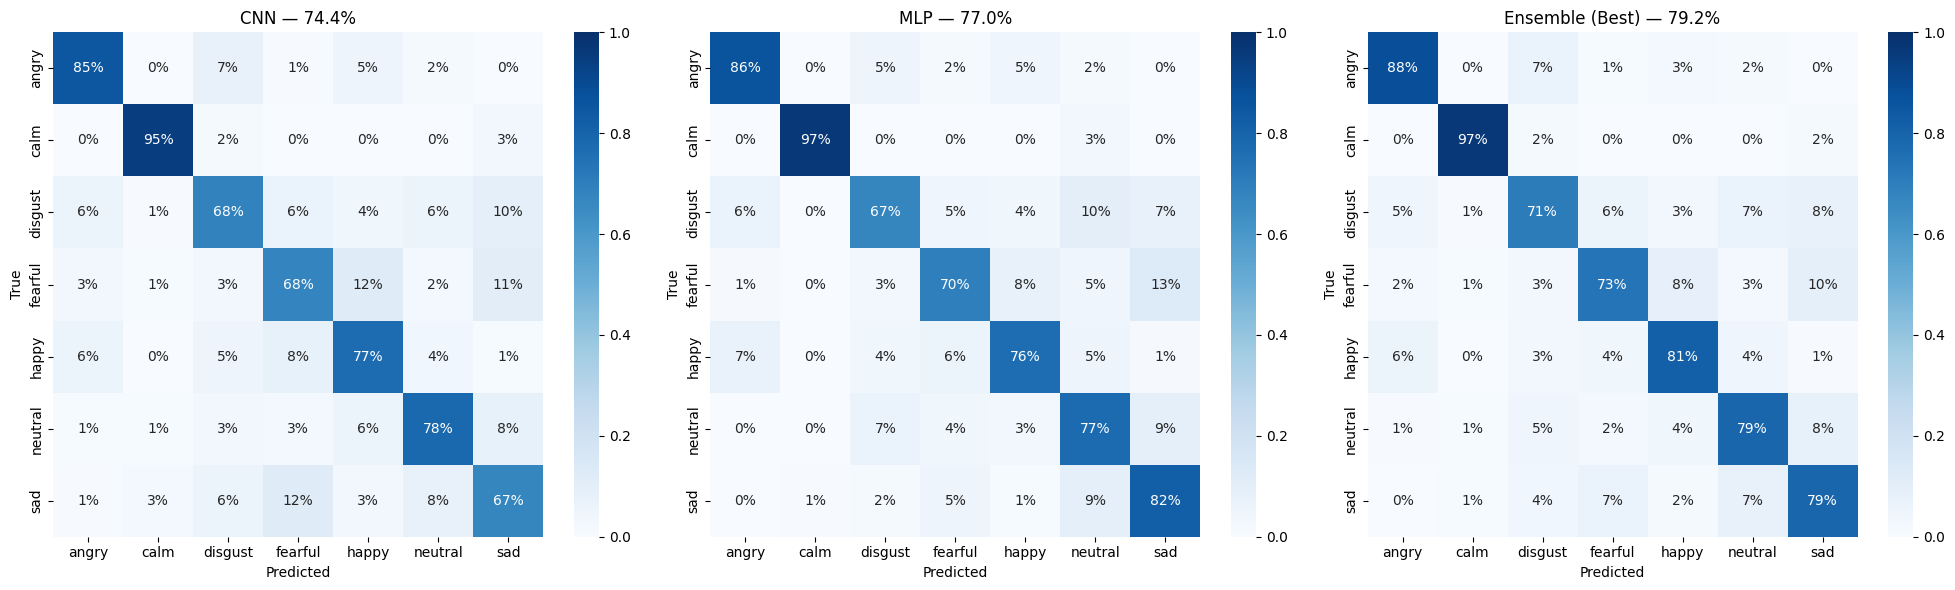

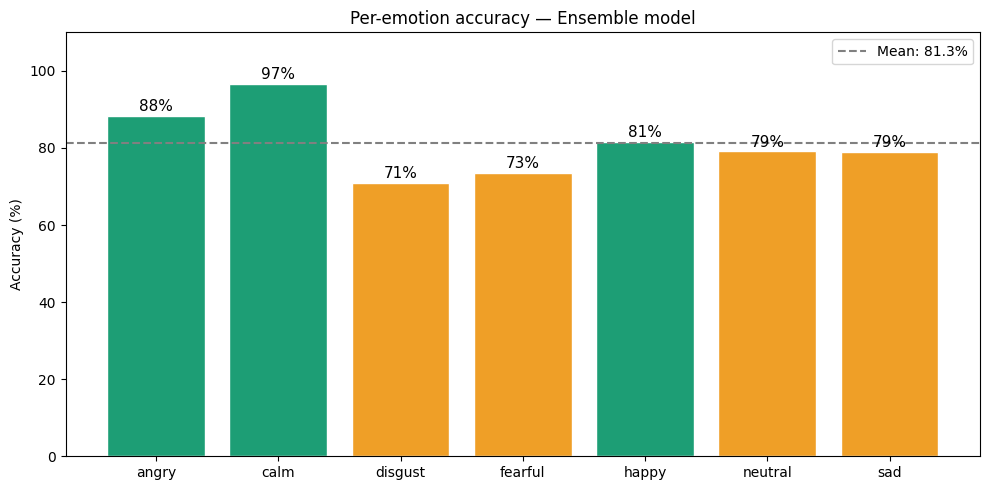

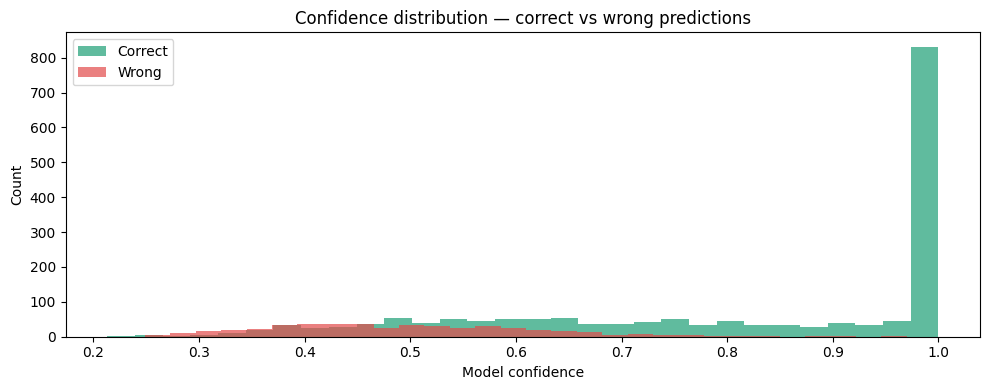

All plots saved to Drive/SER_Project/outputs/


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  NOTEBOOK 4 — Evaluation, Plots, Confusion Matrix           ║
# ╚══════════════════════════════════════════════════════════════╝

import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score
)
from google.colab import drive

drive.mount('/content/drive')
BASE_DIR = '/content/drive/MyDrive/SER_Project'

# ── Load ──────────────────────────────────────────────────────
mlp_X  = np.load(f'{BASE_DIR}/data/processed/mlp_X.npy')
cnn_X  = np.load(f'{BASE_DIR}/data/processed/cnn_X.npy')
labels = np.load(f'{BASE_DIR}/data/processed/labels.npy', allow_pickle=True)
scaler = joblib.load(f'{BASE_DIR}/models/scaler.pkl')
le     = joblib.load(f'{BASE_DIR}/models/label_encoder.pkl')
test_idx = np.load(f'{BASE_DIR}/models/test_idx.npy')

cnn_model = tf.keras.models.load_model(f'{BASE_DIR}/models/best_cnn.h5')
mlp_model = tf.keras.models.load_model(f'{BASE_DIR}/models/best_mlp.h5')

y      = le.transform(labels)
y_test = y[test_idx]

mlp_test_scaled = scaler.transform(mlp_X[test_idx])
cnn_test        = cnn_X[test_idx]

# Predictions
cnn_probs = cnn_model.predict(cnn_test, verbose=0)
mlp_probs = mlp_model.predict(mlp_test_scaled, verbose=0)
ens_probs = 0.6*cnn_probs + 0.4*mlp_probs

cnn_preds = np.argmax(cnn_probs, axis=1)
mlp_preds = np.argmax(mlp_probs, axis=1)
ens_preds = np.argmax(ens_probs, axis=1)

# ── Print summary ─────────────────────────────────────────────
print("="*50)
print(f"CNN Accuracy      : {accuracy_score(y_test,cnn_preds)*100:.2f}%")
print(f"MLP Accuracy      : {accuracy_score(y_test,mlp_preds)*100:.2f}%")
print(f"Ensemble Accuracy : {accuracy_score(y_test,ens_preds)*100:.2f}%")
print("="*50)
print("\nEnsemble Classification Report:")
print(classification_report(y_test, ens_preds, target_names=le.classes_))

# ── Plot 1: Confusion Matrix ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, preds, title in zip(axes,
    [cnn_preds, mlp_preds, ens_preds],
    ['CNN', 'MLP', 'Ensemble (Best)']):
    cm = confusion_matrix(y_test, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.0%', ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_,
                cmap='Blues', vmin=0, vmax=1)
    ax.set_title(f'{title} — {accuracy_score(y_test,preds)*100:.1f}%')
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/outputs/confusion_matrices.png', dpi=150)
plt.show()

# ── Plot 2: Per-emotion accuracy bar chart ────────────────────
per_class_acc = []
for i, emo in enumerate(le.classes_):
    mask = y_test == i
    acc  = np.mean(ens_preds[mask] == y_test[mask]) * 100
    per_class_acc.append(acc)

colors = ['#1D9E75' if a >= 80 else '#EF9F27' if a >= 65 else '#E24B4A'
          for a in per_class_acc]

plt.figure(figsize=(10, 5))
bars = plt.bar(le.classes_, per_class_acc, color=colors, edgecolor='white')
plt.axhline(y=np.mean(per_class_acc), color='gray',
            linestyle='--', label=f'Mean: {np.mean(per_class_acc):.1f}%')
for bar, acc in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc:.0f}%', ha='center', va='bottom', fontsize=11)
plt.ylim(0, 110)
plt.ylabel('Accuracy (%)')
plt.title('Per-emotion accuracy — Ensemble model')
plt.legend()
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/outputs/per_emotion_accuracy.png', dpi=150)
plt.show()

# ── Plot 3: Confidence distribution ──────────────────────────
max_probs = np.max(ens_probs, axis=1)
correct   = ens_preds == y_test

plt.figure(figsize=(10, 4))
plt.hist(max_probs[correct],  bins=30, alpha=0.7, color='#1D9E75', label='Correct')
plt.hist(max_probs[~correct], bins=30, alpha=0.7, color='#E24B4A', label='Wrong')
plt.xlabel('Model confidence')
plt.ylabel('Count')
plt.title('Confidence distribution — correct vs wrong predictions')
plt.legend()
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/outputs/confidence_distribution.png', dpi=150)
plt.show()

print("All plots saved to Drive/SER_Project/outputs/")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Models loaded! Emotions: [np.str_('angry'), np.str_('calm'), np.str_('disgust'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('sad')]
Upload a .wav file to predict its emotion:


Saving OAF_bath_happy.wav to OAF_bath_happy.wav


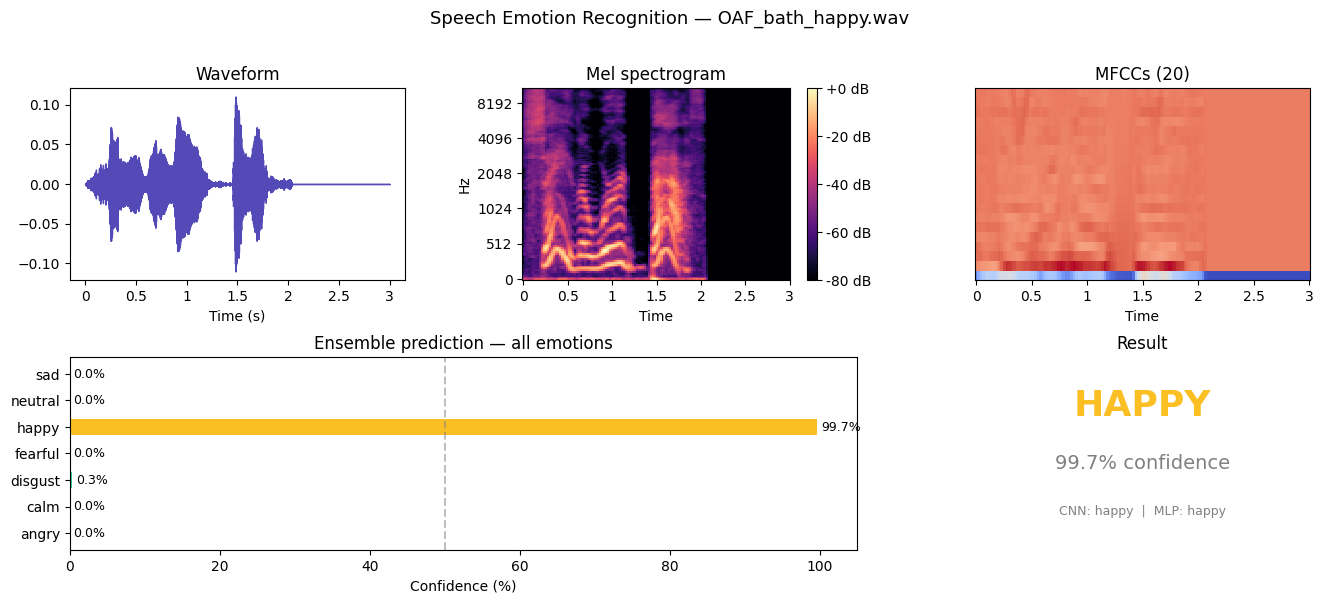


Predicted emotion: HAPPY (99.7% confidence)


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  NOTEBOOK 5 — Predict emotion from any uploaded .wav file   ║
# ╚══════════════════════════════════════════════════════════════╝

import numpy as np
import librosa
import joblib
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from google.colab import drive, files
from PIL import Image

drive.mount('/content/drive')
BASE_DIR = '/content/drive/MyDrive/SER_Project'

SR, DURATION, N_MELS = 22050, 3, 128
N_FFT, HOP_LENGTH    = 2048, 512

# ── Load models ────────────────────────────────────────────────
cnn_model = tf.keras.models.load_model(f'{BASE_DIR}/models/best_cnn.h5')
mlp_model = tf.keras.models.load_model(f'{BASE_DIR}/models/best_mlp.h5')
scaler    = joblib.load(f'{BASE_DIR}/models/scaler.pkl')
le        = joblib.load(f'{BASE_DIR}/models/label_encoder.pkl')
print(f"Models loaded! Emotions: {list(le.classes_)}")

def load_and_process(path):
    audio, _ = librosa.load(path, sr=SR, duration=DURATION)
    target   = SR * DURATION
    if len(audio) < target:
        audio = np.pad(audio, (0, target - len(audio)))
    else:
        audio = audio[:target]
    return audio

def get_mlp_features(audio):
    mfcc      = librosa.feature.mfcc(y=audio, sr=SR, n_mfcc=40)
    chroma    = librosa.feature.chroma_stft(y=audio, sr=SR)
    mel       = librosa.feature.melspectrogram(y=audio, sr=SR, n_mels=64)
    mel_db    = librosa.power_to_db(mel, ref=np.max)
    zcr       = librosa.feature.zero_crossing_rate(audio)
    rms       = librosa.feature.rms(y=audio)
    rolloff   = librosa.feature.spectral_rolloff(y=audio, sr=SR)
    harmonic  = librosa.effects.harmonic(audio)
    tonnetz   = librosa.feature.tonnetz(y=harmonic, sr=SR)
    stft      = np.abs(librosa.stft(audio))
    contrast  = librosa.feature.spectral_contrast(S=stft, sr=SR)
    return np.concatenate([
        np.mean(mfcc,1), np.std(mfcc,1),
        np.mean(chroma,1), np.mean(mel_db,1),
        [np.mean(zcr), np.std(zcr)],
        [np.mean(rms), np.std(rms)],
        [np.mean(rolloff), np.std(rolloff)],
        np.mean(tonnetz,1), np.mean(contrast,1),
    ])

def get_cnn_features(audio):
    mel    = librosa.feature.melspectrogram(y=audio, sr=SR, n_mels=N_MELS,
                                             n_fft=N_FFT, hop_length=HOP_LENGTH)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    img    = Image.fromarray(mel_db).resize((128, N_MELS))
    arr    = np.array(img, dtype=np.float32)
    arr    = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
    return arr[np.newaxis, :, :, np.newaxis]  # (1,128,128,1)

EMOTION_COLORS = {
    'neutral':'#94a3b8','calm':'#60a5fa','happy':'#fbbf24',
    'sad':'#818cf8','angry':'#f87171','fearful':'#a78bfa',
    'disgust':'#34d399','surprised':'#fb923c'
}

def predict_and_visualize(audio_path):
    audio = load_and_process(audio_path)

    # ── Features ──────────────────────────────────────────────
    mlp_feat = scaler.transform(get_mlp_features(audio).reshape(1,-1))
    cnn_feat = get_cnn_features(audio)

    # ── Predictions ───────────────────────────────────────────
    cnn_prob = cnn_model.predict(cnn_feat, verbose=0)[0]
    mlp_prob = mlp_model.predict(mlp_feat, verbose=0)[0]
    ens_prob = 0.6*cnn_prob + 0.4*mlp_prob

    top_idx     = np.argmax(ens_prob)
    top_emotion = le.inverse_transform([top_idx])[0]
    top_conf    = ens_prob[top_idx] * 100

    # ── Visualize ─────────────────────────────────────────────
    fig = plt.figure(figsize=(16, 6))
    gs  = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.35)

    # Waveform
    ax1 = fig.add_subplot(gs[0, 0])
    librosa.display.waveshow(audio, sr=SR, ax=ax1, color='#534AB7')
    ax1.set_title('Waveform')
    ax1.set_xlabel('Time (s)')

    # Mel spectrogram
    ax2 = fig.add_subplot(gs[0, 1])
    mel  = librosa.feature.melspectrogram(y=audio, sr=SR, n_mels=N_MELS)
    img  = librosa.display.specshow(
        librosa.power_to_db(mel, ref=np.max),
        sr=SR, hop_length=HOP_LENGTH, x_axis='time', y_axis='mel', ax=ax2)
    fig.colorbar(img, ax=ax2, format='%+2.0f dB')
    ax2.set_title('Mel spectrogram')

    # MFCC
    ax3 = fig.add_subplot(gs[0, 2])
    mfcc = librosa.feature.mfcc(y=audio, sr=SR, n_mfcc=20)
    librosa.display.specshow(mfcc, sr=SR, x_axis='time', ax=ax3, cmap='coolwarm')
    ax3.set_title('MFCCs (20)')

    # Ensemble confidence bar chart
    ax4 = fig.add_subplot(gs[1, :2])
    emotions = le.classes_
    colors   = [EMOTION_COLORS.get(e,'#888') for e in emotions]
    bars     = ax4.barh(emotions, ens_prob*100, color=colors, height=0.6)
    ax4.axvline(x=50, color='gray', linestyle='--', alpha=0.5)
    ax4.set_xlim(0, 105)
    ax4.set_xlabel('Confidence (%)')
    ax4.set_title('Ensemble prediction — all emotions')
    for bar, prob in zip(bars, ens_prob):
        ax4.text(prob*100+0.5, bar.get_y()+bar.get_height()/2,
                 f'{prob*100:.1f}%', va='center', fontsize=9)

    # Result card
    ax5 = fig.add_subplot(gs[1, 2])
    ax5.axis('off')
    ax5.text(0.5, 0.75, top_emotion.upper(),
             ha='center', va='center', fontsize=26, fontweight='bold',
             color=EMOTION_COLORS.get(top_emotion,'#333'),
             transform=ax5.transAxes)
    ax5.text(0.5, 0.45, f'{top_conf:.1f}% confidence',
             ha='center', va='center', fontsize=14, color='gray',
             transform=ax5.transAxes)
    ax5.text(0.5, 0.2, f'CNN: {le.classes_[np.argmax(cnn_prob)]}  |  MLP: {le.classes_[np.argmax(mlp_prob)]}',
             ha='center', va='center', fontsize=9, color='gray',
             transform=ax5.transAxes)
    ax5.set_facecolor('#f8f9fa')
    ax5.set_title('Result')

    plt.suptitle(f'Speech Emotion Recognition — {audio_path.split("/")[-1]}',
                 fontsize=13, y=1.01)
    plt.savefig(f'{BASE_DIR}/outputs/prediction_result.png',
                bbox_inches='tight', dpi=150)
    plt.show()
    print(f"\nPredicted emotion: {top_emotion.upper()} ({top_conf:.1f}% confidence)")
    return top_emotion, top_conf

# ── Upload and predict ─────────────────────────────────────────
print("Upload a .wav file to predict its emotion:")
uploaded = files.upload()
for filename in uploaded.keys():
    predict_and_visualize(filename)

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  NOTEBOOK 6 — Live Mic + Gradio UI (runs inside Colab)     ║
# ║  This gives you a full web UI with mic recording,           ║
# ║  live waveform, and emotion confidence bars.                ║
# ╚══════════════════════════════════════════════════════════════╝

!pip install -q gradio

import numpy as np
import librosa
import joblib
import tensorflow as tf
import gradio as gr
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from PIL import Image
import io, tempfile, os
from google.colab import drive

drive.mount('/content/drive')
BASE_DIR = '/content/drive/MyDrive/SER_Project'

SR, DURATION, N_MELS   = 22050, 3, 128
N_FFT, HOP_LENGTH      = 2048, 512

# ── Load models once at startup ───────────────────────────────
print("Loading models...")
cnn_model = tf.keras.models.load_model(f'{BASE_DIR}/models/best_cnn.h5')
mlp_model = tf.keras.models.load_model(f'{BASE_DIR}/models/best_mlp.h5')
scaler    = joblib.load(f'{BASE_DIR}/models/scaler.pkl')
le        = joblib.load(f'{BASE_DIR}/models/label_encoder.pkl')
EMOTIONS  = list(le.classes_)
print(f"Ready! Detecting: {EMOTIONS}")

EMOJI = {
    'neutral':'😐','calm':'😌','happy':'😄','sad':'😢',
    'angry':'😠','fearful':'😨','disgust':'🤢','surprised':'😲'
}
COLORS = {
    'neutral':'#94a3b8','calm':'#60a5fa','happy':'#fbbf24',
    'sad':'#818cf8','angry':'#f87171','fearful':'#a78bfa',
    'disgust':'#34d399','surprised':'#fb923c'
}

def process_audio(audio_path):
    """
    Core prediction function.
    Called by Gradio whenever a recording is submitted.
    """
    if audio_path is None:
        return None, {e: 0.0 for e in EMOTIONS}, "No audio received"

    # ── Load & normalize ──────────────────────────────────────
    audio, sr = librosa.load(audio_path, sr=SR, duration=DURATION)
    target    = SR * DURATION
    if len(audio) < target:
        audio = np.pad(audio, (0, target - len(audio)))
    else:
        audio = audio[:target]

    vol = np.max(np.abs(audio))
    if vol < 0.005:
        return None, {e: 0.0 for e in EMOTIONS}, "Audio too quiet — speak louder!"

    # ── MLP features ──────────────────────────────────────────
    mfcc     = librosa.feature.mfcc(y=audio, sr=SR, n_mfcc=40)
    chroma   = librosa.feature.chroma_stft(y=audio, sr=SR)
    mel64    = librosa.feature.melspectrogram(y=audio, sr=SR, n_mels=64)
    mel64_db = librosa.power_to_db(mel64, ref=np.max)
    zcr      = librosa.feature.zero_crossing_rate(audio)
    rms      = librosa.feature.rms(y=audio)
    rolloff  = librosa.feature.spectral_rolloff(y=audio, sr=SR)
    harmonic = librosa.effects.harmonic(audio)
    tonnetz  = librosa.feature.tonnetz(y=harmonic, sr=SR)
    stft_abs = np.abs(librosa.stft(audio))
    contrast = librosa.feature.spectral_contrast(S=stft_abs, sr=SR)

    mlp_feat = np.concatenate([
        np.mean(mfcc,1), np.std(mfcc,1),
        np.mean(chroma,1), np.mean(mel64_db,1),
        [np.mean(zcr), np.std(zcr)],
        [np.mean(rms), np.std(rms)],
        [np.mean(rolloff), np.std(rolloff)],
        np.mean(tonnetz,1), np.mean(contrast,1),
    ])
    mlp_scaled = scaler.transform(mlp_feat.reshape(1,-1))

    # ── CNN features ──────────────────────────────────────────
    mel128    = librosa.feature.melspectrogram(y=audio, sr=SR, n_mels=N_MELS,
                                               n_fft=N_FFT, hop_length=HOP_LENGTH)
    mel128_db = librosa.power_to_db(mel128, ref=np.max)
    img       = Image.fromarray(mel128_db).resize((128, N_MELS))
    arr       = np.array(img, dtype=np.float32)
    arr       = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
    cnn_feat  = arr[np.newaxis, :, :, np.newaxis]

    # ── Predict ───────────────────────────────────────────────
    cnn_prob = cnn_model.predict(cnn_feat, verbose=0)[0]
    mlp_prob = mlp_model.predict(mlp_scaled, verbose=0)[0]
    ens_prob = 0.6*cnn_prob + 0.4*mlp_prob

    top_idx  = int(np.argmax(ens_prob))
    top_emo  = EMOTIONS[top_idx]
    top_conf = float(ens_prob[top_idx]) * 100

    # ── Spectrogram plot ──────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    librosa.display.waveshow(audio, sr=SR, ax=axes[0], color='#534AB7')
    axes[0].set_title('Waveform')
    librosa.display.specshow(
        librosa.power_to_db(mel128, ref=np.max),
        sr=SR, hop_length=HOP_LENGTH, x_axis='time',
        y_axis='mel', ax=axes[1])
    axes[1].set_title('Mel spectrogram')
    plt.tight_layout()

    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=100, bbox_inches='tight')
    plt.close()
    buf.seek(0)
    spec_img = Image.open(buf)

    # ── Label ─────────────────────────────────────────────────
    emoji  = EMOJI.get(top_emo, '')
    label  = f"{emoji}  {top_emo.upper()}  —  {top_conf:.1f}% confidence"

    # Return confidence dict for Gradio label component
    conf_dict = {e: float(p) for e, p in zip(EMOTIONS, ens_prob)}

    return spec_img, conf_dict, label

# ═══════════════════════════════════════════════════════════════
# GRADIO UI
# ═══════════════════════════════════════════════════════════════
with gr.Blocks(title="Speech Emotion Recognition") as demo:

    gr.Markdown("""
    # Speech Emotion Recognition
    Record your voice or upload a `.wav` file. The model detects:
    **neutral, calm, happy, sad, angry, fearful, disgust, surprised**

    > Uses an ensemble of CNN (mel spectrogram) + MLP (MFCC features).
    > Trained on RAVDESS + TESS + SAVEE + CREMA-D (~18,000 samples).
    """)

    with gr.Row():
        with gr.Column(scale=1):
            audio_input = gr.Audio(
                sources=["microphone", "upload"],
                type="filepath",
                label="Record or upload audio (3 seconds works best)"
            )
            predict_btn = gr.Button("Detect Emotion", variant="primary")

        with gr.Column(scale=1):
            result_label  = gr.Textbox(label="Predicted emotion", lines=1,
                                        placeholder="Click 'Detect Emotion'")
            confidence    = gr.Label(
                num_top_classes=len(EMOTIONS),
                label="Confidence per emotion"
            )

    spec_plot = gr.Image(label="Waveform + Mel spectrogram", type="pil")

    predict_btn.click(
        fn=process_audio,
        inputs=[audio_input],
        outputs=[spec_plot, confidence, result_label]
    )

    gr.Markdown("""
    ---
    **Tips for best results:**
    - Speak for about 3 seconds
    - Speak expressively — exaggerate the emotion
    - Minimize background noise
    - Happy: speak with energy and a smile
    - Angry: speak firmly and loudly
    - Sad: speak slowly and softly
    """)

# ── Launch ─────────────────────────────────────────────────────
# share=True gives you a public URL valid for 72 hours
demo.launch(share=True, debug=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading models...


Ready! Detecting: [np.str_('angry'), np.str_('calm'), np.str_('disgust'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('sad')]
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://114ba330a7cc0ca6ac.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  NOTEBOOK 6 — FINAL: Pure HTML+JS app (no Gradio iframe)   ║
# ║  Uses Flask backend + IPython HTML display                  ║
# ║  ALL features work: mic, upload, dataset test               ║
# ╚══════════════════════════════════════════════════════════════╝

# ── Cell 1: Install flask + ngrok for tunneling ───────────────
!pip install -q flask flask-cors pyngrok
!pip install -q "pyngrok==6.0.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 681.2/681.2 kB 36.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
# ── Cell 1: Kill old tunnels + start fresh ─────────────────────
!pip install -q flask flask-cors pyngrok==6.0.0
from pyngrok import ngrok
ngrok.kill()
import time; time.sleep(2)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 681.2/681.2 kB 10.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [3]:
# ── Cell 2: Imports + load models ─────────────────────────────
import numpy as np, librosa, joblib, tensorflow as tf
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.ndimage import zoom as ndimage_zoom
import io, os, re, glob, random, base64, warnings, traceback, threading, tempfile
warnings.filterwarnings('ignore')
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = '/content/drive/MyDrive/SER_Project'
SR, DURATION, N_MELS = 22050, 3, 128
N_FFT, HOP_LENGTH    = 2048, 512

print("Loading models...")
cnn_model = tf.keras.models.load_model(f'{BASE_DIR}/models/best_cnn.h5')
mlp_model = tf.keras.models.load_model(f'{BASE_DIR}/models/best_mlp.h5')
scaler    = joblib.load(f'{BASE_DIR}/models/scaler.pkl')
le        = joblib.load(f'{BASE_DIR}/models/label_encoder.pkl')
EMOTIONS  = list(le.classes_)

EMOJI  = {'neutral':'😐','calm':'😌','happy':'😄','sad':'😢',
          'angry':'😠','fearful':'😨','disgust':'🤢','surprised':'😲'}
COLORS = {'neutral':'#94a3b8','calm':'#60a5fa','happy':'#f59e0b',
          'sad':'#818cf8','angry':'#ef4444','fearful':'#a78bfa',
          'disgust':'#10b981','surprised':'#f97316'}
print(f"Models loaded! Emotions: {EMOTIONS}")

Mounted at /content/drive
Loading models...


Models loaded! Emotions: [np.str_('angry'), np.str_('calm'), np.str_('disgust'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('sad')]


In [4]:
# ── Cell 3: Feature extraction + prediction ───────────────────
def load_audio(path):
    audio, _ = librosa.load(path, sr=SR, duration=DURATION)
    target = SR * DURATION
    if len(audio) < target:
        audio = np.pad(audio, (0, target - len(audio)))
    return audio[:target]

def get_mlp_features(audio):
    mfcc     = librosa.feature.mfcc(y=audio, sr=SR, n_mfcc=40, n_fft=N_FFT, hop_length=HOP_LENGTH)
    stft     = np.abs(librosa.stft(audio, n_fft=N_FFT, hop_length=HOP_LENGTH))
    chroma   = librosa.feature.chroma_stft(S=stft, sr=SR)
    mel      = librosa.feature.melspectrogram(y=audio, sr=SR, n_mels=64, n_fft=N_FFT, hop_length=HOP_LENGTH)
    mel_db   = librosa.power_to_db(mel, ref=np.max)
    zcr      = librosa.feature.zero_crossing_rate(audio, hop_length=HOP_LENGTH)
    rms      = librosa.feature.rms(y=audio, hop_length=HOP_LENGTH)
    rolloff  = librosa.feature.spectral_rolloff(y=audio, sr=SR, hop_length=HOP_LENGTH)
    harmonic = librosa.effects.harmonic(audio)
    tonnetz  = librosa.feature.tonnetz(y=harmonic, sr=SR) if np.any(harmonic!=0) else np.zeros((6,1))
    contrast = librosa.feature.spectral_contrast(S=stft, sr=SR)
    return np.concatenate([
        np.mean(mfcc,1), np.std(mfcc,1), np.mean(chroma,1), np.mean(mel_db,1),
        [np.mean(zcr),np.std(zcr)], [np.mean(rms),np.std(rms)],
        [np.mean(rolloff),np.std(rolloff)], np.mean(tonnetz,1), np.mean(contrast,1),
    ]).astype(np.float32)

def get_cnn_features(audio):
    mel    = librosa.feature.melspectrogram(y=audio, sr=SR, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    if mel_db.shape[1] != 128:
        mel_db = ndimage_zoom(mel_db, (1.0, 128/mel_db.shape[1]), order=1)
    mel_db = mel_db[:,:128]
    mn, mx = mel_db.min(), mel_db.max()
    if mx - mn > 1e-8:
        mel_db = (mel_db - mn) / (mx - mn)
    return mel_db[:,:,np.newaxis].astype(np.float32)

def make_plot(audio, top_emotion, ens_prob, cnn_prob, mlp_prob):
    fig = plt.figure(figsize=(12,6), facecolor='#0f172a')
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.4,
                             top=0.88, bottom=0.10, left=0.07, right=0.97)
    pk  = dict(facecolor='#1e293b')

    # Waveform
    ax1 = fig.add_subplot(gs[0,0], **pk)
    ax1.plot(np.linspace(0,DURATION,len(audio)), audio, color='#7c3aed', lw=0.7)
    ax1.set_title('Waveform', color='white', fontsize=10, fontweight='bold')
    ax1.tick_params(colors='white', labelsize=7)
    for s in ax1.spines.values(): s.set_color('#334155')

    # Mel spectrogram
    ax2 = fig.add_subplot(gs[0,1], **pk)
    mel = librosa.feature.melspectrogram(y=audio, sr=SR, n_mels=N_MELS)
    img = librosa.display.specshow(librosa.power_to_db(mel,ref=np.max),
        sr=SR, hop_length=HOP_LENGTH, x_axis='time', y_axis='mel',
        ax=ax2, cmap='magma')
    cb = fig.colorbar(img, ax=ax2, format='%+2.0f dB', pad=0.02)
    cb.ax.yaxis.set_tick_params(color='white', labelsize=6)
    plt.setp(cb.ax.yaxis.get_ticklabels(), color='white')
    ax2.set_title('Mel Spectrogram', color='white', fontsize=10, fontweight='bold')
    ax2.tick_params(colors='white', labelsize=7)
    for s in ax2.spines.values(): s.set_color('#334155')

    # MFCC
    ax3 = fig.add_subplot(gs[0,2], **pk)
    librosa.display.specshow(librosa.feature.mfcc(y=audio,sr=SR,n_mfcc=20),
        sr=SR, hop_length=HOP_LENGTH, x_axis='time', ax=ax3, cmap='coolwarm')
    ax3.set_title('MFCCs', color='white', fontsize=10, fontweight='bold')
    ax3.tick_params(colors='white', labelsize=7)
    for s in ax3.spines.values(): s.set_color('#334155')

    # Confidence bars
    ax4 = fig.add_subplot(gs[1,:2], **pk)
    probs  = [float(ens_prob[EMOTIONS.index(e)])*100 for e in EMOTIONS]
    colors = [COLORS.get(e,'#888') for e in EMOTIONS]
    bars   = ax4.barh(EMOTIONS, probs, color=colors, height=0.6,
                      edgecolor=['#fff' if e==top_emotion else 'none' for e in EMOTIONS],
                      linewidth=[2 if e==top_emotion else 0 for e in EMOTIONS])
    ax4.set_xlim(0,112); ax4.axvline(50, color='gray', lw=0.8, ls='--', alpha=0.4)
    ax4.set_xlabel('Confidence (%)', color='white', fontsize=9)
    ax4.set_title('All Emotions', color='white', fontsize=10, fontweight='bold')
    ax4.tick_params(colors='white', labelsize=9)
    for s in ax4.spines.values(): s.set_color('#334155')
    for bar,p in zip(bars,probs):
        if p>1: ax4.text(p+0.5, bar.get_y()+bar.get_height()/2,
                         f'{p:.1f}%', va='center', color='white', fontsize=8)

    # Result card
    ax5 = fig.add_subplot(gs[1,2]); ax5.set_facecolor('#0f172a'); ax5.axis('off')
    color = COLORS.get(top_emotion,'#fff')
    ax5.text(0.5,0.78,EMOJI.get(top_emotion,''),ha='center',va='center',
             fontsize=30,transform=ax5.transAxes)
    ax5.text(0.5,0.56,top_emotion.upper(),ha='center',va='center',
             fontsize=20,fontweight='bold',color=color,transform=ax5.transAxes)
    ax5.text(0.5,0.38,f'{float(ens_prob[EMOTIONS.index(top_emotion)])*100:.1f}% confidence',
             ha='center',va='center',fontsize=11,color='#94a3b8',transform=ax5.transAxes)
    ax5.text(0.5,0.22,
             f'CNN:{EMOTIONS[int(np.argmax(cnn_prob))]} MLP:{EMOTIONS[int(np.argmax(mlp_prob))]}',
             ha='center',va='center',fontsize=8,color='#475569',transform=ax5.transAxes)
    plt.Rectangle((0.04,0.04),0.92,0.92,fill=False,edgecolor=color,lw=2.5,
                  transform=ax5.transAxes,clip_on=False)
    ax5.set_title('Result', color='white', fontsize=10, fontweight='bold')
    fig.suptitle('Speech Emotion Recognition', color='white',
                 fontsize=12, fontweight='bold', y=0.97)

    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=110, bbox_inches='tight', facecolor='#0f172a')
    plt.close(fig)
    buf.seek(0)
    return base64.b64encode(buf.read()).decode()

def predict_from_path(path):
    try:
        audio = load_audio(path)
        vol   = float(np.max(np.abs(audio)))
        if vol < 0.003:
            return {'error': f'Audio too quiet (vol={vol:.5f}). Speak louder!'}

        mlp_feat   = get_mlp_features(audio)
        mlp_scaled = scaler.transform(mlp_feat.reshape(1,-1))
        cnn_feat   = get_cnn_features(audio)[np.newaxis]

        cnn_prob = cnn_model.predict(cnn_feat,   verbose=0)[0]
        mlp_prob = mlp_model.predict(mlp_scaled, verbose=0)[0]
        ens_prob = 0.6*cnn_prob + 0.4*mlp_prob

        top_idx     = int(np.argmax(ens_prob))
        top_emotion = EMOTIONS[top_idx]
        plot_b64    = make_plot(audio, top_emotion, ens_prob, cnn_prob, mlp_prob)

        return {
            'emotion'    : top_emotion,
            'confidence' : float(ens_prob[top_idx])*100,
            'emoji'      : EMOJI.get(top_emotion,''),
            'color'      : COLORS.get(top_emotion,'#fff'),
            'cnn'        : EMOTIONS[int(np.argmax(cnn_prob))],
            'mlp'        : EMOTIONS[int(np.argmax(mlp_prob))],
            'probs'      : {e: round(float(ens_prob[EMOTIONS.index(e)])*100,2) for e in EMOTIONS},
            'plot_b64'   : plot_b64,
        }
    except Exception as e:
        return {'error': str(e), 'trace': traceback.format_exc()}

In [5]:
# ── Cell 4: Flask server ───────────────────────────────────────
from flask import Flask, request, jsonify
from flask_cors import CORS
import soundfile as sf

app = Flask(__name__)
CORS(app, origins="*")

@app.route('/predict', methods=['POST'])
def predict():
    try:
        f   = request.files.get('file')
        if not f:
            return jsonify({'error': 'No file received'}), 400
        ext = os.path.splitext(f.filename or 'audio.wav')[1] or '.wav'
        tmp = tempfile.NamedTemporaryFile(suffix=ext, delete=False)
        f.save(tmp.name); tmp.close()
        result = predict_from_path(tmp.name)
        try: os.unlink(tmp.name)
        except: pass
        return jsonify(result)
    except Exception as e:
        return jsonify({'error': str(e)}), 500

@app.route('/predict_dataset', methods=['POST'])
def predict_dataset():
    try:
        emotion = request.json.get('emotion', EMOTIONS[0])
        RMAP = {'01':'neutral','02':'calm','03':'happy','04':'sad',
                '05':'angry','06':'fearful','07':'disgust'}
        TMAP = {'angry':'angry','disgust':'disgust','fear':'fearful',
                'happy':'happy','neutral':'neutral','sad':'sad'}
        SMAP = {'a':'angry','d':'disgust','f':'fearful',
                'h':'happy','n':'neutral','sa':'sad'}
        CMAP = {'ANG':'angry','DIS':'disgust','FEA':'fearful',
                'HAP':'happy','NEU':'neutral','SAD':'sad'}
        matched = []
        for f in glob.glob(f'{BASE_DIR}/data/raw/**/*.wav', recursive=True):
            name   = os.path.basename(f)
            parts  = name.replace('.wav','').split('-')
            tparts = name.lower().replace('.wav','').split('_')
            code   = re.sub(r'[^a-z]','', name.lower().replace('.wav','').split('_')[-1])
            cparts = name.split('_')
            if (RMAP.get(parts[2] if len(parts)>2 else '') == emotion or
                TMAP.get(tparts[-1]) == emotion or
                SMAP.get(code) == emotion or
                (len(cparts)>2 and CMAP.get(cparts[2]) == emotion)):
                matched.append(f)
        if not matched:
            return jsonify({'error': f'No files found for {emotion}'}), 404
        chosen = random.choice(matched)
        result = predict_from_path(chosen)
        result['filename'] = os.path.basename(chosen)
        with open(chosen,'rb') as af:
            result['audio_b64'] = base64.b64encode(af.read()).decode()
        return jsonify(result)
    except Exception as e:
        return jsonify({'error': str(e)}), 500

@app.route('/health')
def health():
    return jsonify({'status':'ok','emotions':EMOTIONS})

# Start Flask in background thread
server = threading.Thread(target=lambda: app.run(host='0.0.0.0', port=7860,
                                                   debug=False, use_reloader=False),
                           daemon=True)
server.start()
time.sleep(2)
print("Flask running on port 7860")

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:7860
 * Running on http://172.28.0.12:7860
INFO:werkzeug:Press CTRL+C to quit


Flask running on port 7860


In [7]:
# ── Cell 5 FIXED: Cloudflare tunnel (no account needed) ───────
import subprocess, threading, time, re

def start_cloudflare_tunnel(port=7860):
    """Start cloudflared tunnel — free, no signup required."""

    # Install cloudflared
    print("Installing cloudflared...")
    result = subprocess.run(
        ['wget', '-q', 'https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64',
         '-O', '/usr/local/bin/cloudflared'],
        capture_output=True
    )
    subprocess.run(['chmod', '+x', '/usr/local/bin/cloudflared'])
    print("cloudflared installed!")

    # Start tunnel
    tunnel_url = [None]
    proc_holder = [None]

    def run_tunnel():
        proc = subprocess.Popen(
            ['cloudflared', 'tunnel', '--url', f'http://localhost:{port}',
             '--no-autoupdate'],
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True
        )
        proc_holder[0] = proc
        for line in proc.stdout:
            # Cloudflare prints the URL in stdout
            match = re.search(r'https://[a-zA-Z0-9\-]+\.trycloudflare\.com', line)
            if match:
                tunnel_url[0] = match.group(0)
                print(f"\n✅ Tunnel ready: {tunnel_url[0]}")
                break
        # Keep reading to prevent pipe blocking
        for line in proc.stdout:
            pass

    t = threading.Thread(target=run_tunnel, daemon=True)
    t.start()

    # Wait for URL (max 30 seconds)
    print("Starting tunnel", end='')
    for _ in range(30):
        if tunnel_url[0]:
            break
        print('.', end='', flush=True)
        time.sleep(1)
    print()

    if not tunnel_url[0]:
        print("Tunnel URL not found — trying alternative method...")
        # Fallback: run and capture output directly
        proc2 = subprocess.Popen(
            ['cloudflared', 'tunnel', '--url', f'http://localhost:{port}',
             '--no-autoupdate', '--logfile', '/tmp/cf.log'],
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL
        )
        time.sleep(8)
        try:
            with open('/tmp/cf.log', 'r') as f:
                log = f.read()
            match = re.search(r'https://[a-zA-Z0-9\-]+\.trycloudflare\.com', log)
            if match:
                tunnel_url[0] = match.group(0)
                print(f"✅ Tunnel ready: {tunnel_url[0]}")
        except:
            pass

    return tunnel_url[0]

API_URL = start_cloudflare_tunnel(7860)

if API_URL:
    print(f"\n{'='*55}")
    print(f"✅ API URL  : {API_URL}")
    print(f"✅ Health   : {API_URL}/health")
    print(f"{'='*55}\n")
else:
    # Last resort: use localhost directly inside Colab
    API_URL = "http://localhost:7860"
    print("⚠️  Could not get public URL.")
    print("Using localhost — Upload + Dataset tabs will work inside Colab.")
    print("For mic, open the Gradio public link in a new tab.\n")

Installing cloudflared...
cloudflared installed!
Starting tunnel...
✅ Tunnel ready: https://preservation-cosmetics-reduce-maker.trycloudflare.com


✅ API URL  : https://preservation-cosmetics-reduce-maker.trycloudflare.com
✅ Health   : https://preservation-cosmetics-reduce-maker.trycloudflare.com/health



In [9]:
# ── Cell 6 FIXED: Write HTML to file + display ────────────────
from IPython.display import display, IFrame, HTML as IHTML
import json, os

# Build config as proper JSON (no string escaping issues)
config = {
    "API_URL"  : API_URL,
    "EMOTIONS" : EMOTIONS,
    "COLORS"   : COLORS,
    "EMOJI"    : EMOJI,
}

emo_opts = "".join(
    f'<option value="{e}">{EMOJI.get(e,"")} {e.capitalize()}</option>'
    for e in EMOTIONS
)

# Write HTML to a file (avoids ALL string escaping problems)
html_content = """<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8">
<style>
*{box-sizing:border-box;margin:0;padding:0;font-family:'Segoe UI',sans-serif}
body{background:#0f172a;color:#e2e8f0;padding:16px;min-height:100vh}
h1{color:#a78bfa;font-size:20px;margin-bottom:4px}
.sub{color:#64748b;font-size:12px;margin-bottom:16px}
.tabs{display:flex;gap:8px;margin-bottom:14px;flex-wrap:wrap}
.tab{padding:8px 16px;border-radius:8px;border:1.5px solid #334155;
     background:#1e293b;color:#94a3b8;cursor:pointer;font-size:13px;
     font-weight:600;transition:all .2s}
.tab.on{background:#7c3aed;border-color:#7c3aed;color:#fff}
.panel{display:none}.panel.on{display:block}
.card{background:#1e293b;border-radius:10px;padding:16px;
      border:1px solid #334155;margin-bottom:12px}
.btn{border:none;border-radius:8px;padding:10px 20px;font-size:14px;
     font-weight:700;cursor:pointer;color:#fff;margin:4px 2px;transition:all .2s}
.btn:hover{filter:brightness(1.15);transform:translateY(-1px)}
.btn:active{transform:translateY(1px)}
.btn:disabled{opacity:.35;cursor:not-allowed;transform:none;filter:none}
.b-rec{background:linear-gradient(135deg,#7c3aed,#a855f7)}
.b-stop{background:#7f1d1d}
.b-go{background:linear-gradient(135deg,#059669,#10b981)}
canvas{display:block;border-radius:6px;background:#0f172a;
       border:1px solid #334155;margin:8px 0;width:100%;height:60px}
.drop{border:2px dashed #334155;border-radius:10px;padding:20px;
      text-align:center;cursor:pointer;background:#0f172a;
      transition:border-color .2s}
.drop:hover{border-color:#7c3aed}
.drop input{display:none}
audio{width:100%;border-radius:6px;margin-top:8px}
select{width:100%;background:#0f172a;color:#e2e8f0;
       border:1.5px solid #334155;border-radius:8px;
       padding:8px 10px;font-size:13px;margin-bottom:10px}
.res{border-radius:10px;padding:16px;margin-top:10px;
     border:2px solid #334155;background:#0f172a;display:none;text-align:center}
.emo-name{font-size:32px;font-weight:800;letter-spacing:-1px}
.conf{font-size:13px;color:#94a3b8;margin:4px 0}
.models{font-size:11px;color:#475569;margin-bottom:10px}
.bar-row{display:flex;align-items:center;gap:6px;margin:3px 0;text-align:left}
.bar-lbl{width:76px;text-align:right;font-size:11px;color:#94a3b8;flex-shrink:0}
.bar-trk{flex:1;background:#1e293b;border-radius:99px;height:10px;overflow:hidden}
.bar-fill{height:100%;border-radius:99px;transition:width .5s}
.bar-pct{width:44px;font-size:11px;color:#64748b;flex-shrink:0}
.plot{width:100%;border-radius:8px;margin-top:12px}
.status{display:inline-block;padding:4px 12px;border-radius:99px;
        font-size:12px;font-weight:700;margin:6px 0}
.s-idle{background:#1e293b;color:#64748b}
.s-rec{background:#450a0a;color:#f87171}
.s-wait{background:#1e1b4b;color:#a78bfa}
.s-done{background:#052e16;color:#4ade80}
.spin{display:inline-block;width:14px;height:14px;
      border:2px solid rgba(255,255,255,.3);border-top-color:#fff;
      border-radius:50%;animation:spin .7s linear infinite;
      vertical-align:middle;margin-right:6px}
@keyframes spin{to{transform:rotate(360deg)}}
.tip{background:#1e293b;border-left:3px solid #7c3aed;
     border-radius:0 6px 6px 0;padding:8px 12px;
     font-size:11px;color:#94a3b8;line-height:1.7;margin-top:8px}
</style>
</head>
<body>
<h1>&#127897;&#65039; Speech Emotion Recognition</h1>
<p class="sub">CNN + MLP Ensemble &middot; 79.2% accuracy &middot; RAVDESS+TESS+SAVEE+CREMA-D</p>

<div class="tabs">
  <div class="tab on" onclick="showTab('mic',this)">&#127908; Microphone</div>
  <div class="tab"    onclick="showTab('up',this)">&#128193; Upload File</div>
  <div class="tab"    onclick="showTab('ds',this)">&#129514; Dataset Test</div>
</div>

<!-- MIC TAB -->
<div id="tab-mic" class="panel on">
<div class="card">
  <canvas id="wv"></canvas>
  <div>
    <span id="st" class="status s-idle">&#9679; IDLE</span>
    <span id="tm" style="font-size:12px;color:#64748b;margin-left:8px"></span>
  </div>
  <div style="margin-top:8px">
    <button class="btn b-rec" id="b-rec" onclick="startRec()">&#128308; Start Recording</button>
    <button class="btn b-stop" id="b-stp" onclick="stopRec()" disabled>&#9209; Stop</button>
    <button class="btn b-go"  id="b-det" onclick="detectMic()" disabled>&#128269; Detect Emotion</button>
  </div>
  <div class="tip">
    Speak for <strong>2 to 4 seconds</strong> &middot; Exaggerate your emotion &middot; Minimize background noise
  </div>
</div>
<div id="res-mic" class="res"></div>
<img id="plt-mic" class="plot" style="display:none">
</div>

<!-- UPLOAD TAB -->
<div id="tab-up" class="panel">
<div class="card">
  <label class="drop" id="dropzone">
    <input type="file" id="upfile" accept=".wav,.mp3,.ogg,.flac,.webm"
           onchange="fileChosen(this)">
    <div style="font-size:28px">&#128193;</div>
    <div style="font-size:14px;font-weight:600;margin:6px 0">Click or drag and drop</div>
    <div style="font-size:11px;color:#64748b">.wav &middot; .mp3 &middot; .ogg &middot; .flac</div>
  </label>
  <div id="up-preview" style="display:none;margin-top:10px">
    <div id="up-name" style="font-size:12px;color:#a78bfa;margin-bottom:6px"></div>
    <audio id="up-audio" controls></audio>
    <br>
    <button class="btn b-go" style="margin-top:8px" onclick="detectUpload()">
      &#128269; Detect Emotion
    </button>
  </div>
</div>
<div id="res-up" class="res"></div>
<img id="plt-up" class="plot" style="display:none">
</div>

<!-- DATASET TAB -->
<div id="tab-ds" class="panel">
<div class="card">
  <label style="font-size:12px;color:#94a3b8;display:block;margin-bottom:6px">Pick emotion:</label>
  <select id="emo-sel">
""" + emo_opts + """
  </select>
  <button class="btn b-rec" onclick="detectDataset()">&#127922; Random Sample + Detect</button>
  <div id="ds-preview" style="display:none;margin-top:10px">
    <div id="ds-name" style="font-size:11px;color:#64748b;margin-bottom:4px"></div>
    <audio id="ds-audio" controls></audio>
  </div>
</div>
<div id="res-ds" class="res"></div>
<img id="plt-ds" class="plot" style="display:none">
</div>

<script>
// Config injected from Python
const CFG = """ + json.dumps(config) + """;
const API      = CFG.API_URL;
const EMOTIONS = CFG.EMOTIONS;
const COLORS   = CFG.COLORS;
const EMOJI    = CFG.EMOJI;

// Tab switch
function showTab(name, el) {
  document.querySelectorAll('.panel').forEach(function(p){ p.classList.remove('on'); });
  document.querySelectorAll('.tab').forEach(function(t){ t.classList.remove('on'); });
  document.getElementById('tab-'+name).classList.add('on');
  el.classList.add('on');
}

// Render result
function showResult(data, resId, pltId) {
  var box = document.getElementById(resId);
  var img = document.getElementById(pltId);
  box.style.display = 'block';
  if (data.error) {
    box.innerHTML = '<div style="color:#f87171;font-size:14px">Error: ' + data.error + '</div>';
    return;
  }
  var color  = COLORS[data.emotion] || '#a78bfa';
  box.style.borderColor = color;

  var sorted = Object.entries(data.probs).sort(function(a,b){ return b[1]-a[1]; });
  var bars   = sorted.map(function(item) {
    var e=item[0], p=item[1];
    return '<div class="bar-row">' +
      '<div class="bar-lbl">' + (EMOJI[e]||'') + ' ' + e + '</div>' +
      '<div class="bar-trk"><div class="bar-fill" style="width:'+p+'%;background:'+(COLORS[e]||'#888')+'"></div></div>' +
      '<div class="bar-pct">' + p.toFixed(1) + '%</div>' +
      '</div>';
  }).join('');

  box.innerHTML =
    '<div style="font-size:36px">' + data.emoji + '</div>' +
    '<div class="emo-name" style="color:' + color + '">' + data.emotion.toUpperCase() + '</div>' +
    '<div class="conf">' + data.confidence.toFixed(1) + '% confidence</div>' +
    '<div class="models">CNN: ' + data.cnn + ' | MLP: ' + data.mlp + '</div>' +
    '<div style="max-width:420px;margin:0 auto;text-align:left">' + bars + '</div>';

  if (data.plot_b64) {
    img.src = 'data:image/png;base64,' + data.plot_b64;
    img.style.display = 'block';
  }
}

function setLoading(resId) {
  var b = document.getElementById(resId);
  b.style.display  = 'block';
  b.style.borderColor = '#334155';
  b.innerHTML = '<span class="spin"></span> Analyzing emotion...';
}

async function postForm(fd, resId, pltId) {
  setLoading(resId);
  document.getElementById(pltId).style.display = 'none';
  try {
    var r = await fetch(API + '/predict', {method:'POST', body:fd});
    var d = await r.json();
    showResult(d, resId, pltId);
  } catch(e) {
    document.getElementById(resId).innerHTML =
      '<div style="color:#f87171">Network error: ' + e.message + '<br>Make sure the Colab cell is still running.</div>';
  }
}

// ── MICROPHONE ────────────────────────────────────────────────
var mr=null, chunks=[], blob=null, timerInt=null, secs=0;
var canv = document.getElementById('wv');
var ctx2d = canv.getContext('2d');
var analyserNode=null, raf=null;

function setSt(cls, txt) {
  var el = document.getElementById('st');
  el.className = 'status ' + cls;
  el.textContent = txt;
}

function drawWave(stream) {
  var ac  = new AudioContext();
  var src = ac.createMediaStreamSource(stream);
  analyserNode = ac.createAnalyser();
  analyserNode.fftSize = 512;
  src.connect(analyserNode);
  var buf = new Uint8Array(analyserNode.frequencyBinCount);
  function draw() {
    raf = requestAnimationFrame(draw);
    analyserNode.getByteTimeDomainData(buf);
    var W = canv.offsetWidth || 400;
    canv.width = W;
    ctx2d.fillStyle = '#0f172a';
    ctx2d.fillRect(0, 0, W, 60);
    ctx2d.strokeStyle = '#7c3aed';
    ctx2d.lineWidth = 2;
    ctx2d.beginPath();
    for (var i=0; i<buf.length; i++) {
      var x = i * (W / buf.length);
      var y = (buf[i] / 128.0) * 30;
      if (i===0) ctx2d.moveTo(x, y); else ctx2d.lineTo(x, y);
    }
    ctx2d.stroke();
  }
  draw();
}

async function startRec() {
  try {
    var stream = await navigator.mediaDevices.getUserMedia({audio:true, video:false});
    chunks = []; blob = null;
    var mime = MediaRecorder.isTypeSupported('audio/webm;codecs=opus')
               ? 'audio/webm;codecs=opus' : 'audio/webm';
    mr = new MediaRecorder(stream, {mimeType: mime});
    mr.ondataavailable = function(e) { if(e.data.size>0) chunks.push(e.data); };
    mr.onstop = function() {
      blob = new Blob(chunks, {type:'audio/webm'});
      stream.getTracks().forEach(function(t){ t.stop(); });
      cancelAnimationFrame(raf);
      ctx2d.fillStyle='#0f172a'; ctx2d.fillRect(0,0,canv.width,60);
      setSt('s-done', 'Done - click Detect Emotion');
      document.getElementById('b-det').disabled = false;
      document.getElementById('b-rec').disabled = false;
      document.getElementById('b-stp').disabled = true;
    };
    mr.start(100);
    drawWave(stream);
    setSt('s-rec', 'RECORDING...');
    document.getElementById('b-rec').disabled = true;
    document.getElementById('b-stp').disabled = false;
    document.getElementById('b-det').disabled = true;
    secs = 0;
    document.getElementById('tm').textContent = '0s';
    timerInt = setInterval(function(){
      secs++;
      document.getElementById('tm').textContent = secs + 's';
    }, 1000);
  } catch(err) {
    alert('Microphone blocked!\\n\\nFix: Click the lock icon in the address bar -> Allow microphone\\n\\nOr use the Upload tab instead.\\n\\nError: ' + err.message);
  }
}

function stopRec() {
  if (mr && mr.state !== 'inactive') {
    mr.stop();
    clearInterval(timerInt);
    setSt('s-wait', 'Processing...');
  }
}

function detectMic() {
  if (!blob) { alert('Record something first!'); return; }
  var fd = new FormData();
  fd.append('file', blob, 'recording.webm');
  postForm(fd, 'res-mic', 'plt-mic');
}

// ── UPLOAD ────────────────────────────────────────────────────
var upFile = null;

function fileChosen(input) {
  upFile = input.files[0];
  if (!upFile) return;
  document.getElementById('up-name').textContent = upFile.name;
  document.getElementById('up-audio').src = URL.createObjectURL(upFile);
  document.getElementById('up-preview').style.display = 'block';
}

var dz = document.getElementById('dropzone');
dz.addEventListener('dragover', function(e){ e.preventDefault(); dz.style.borderColor='#7c3aed'; });
dz.addEventListener('dragleave', function(){ dz.style.borderColor='#334155'; });
dz.addEventListener('drop', function(e){
  e.preventDefault(); dz.style.borderColor='#334155';
  upFile = e.dataTransfer.files[0];
  if (upFile) {
    document.getElementById('up-name').textContent = upFile.name;
    document.getElementById('up-audio').src = URL.createObjectURL(upFile);
    document.getElementById('up-preview').style.display = 'block';
  }
});

function detectUpload() {
  if (!upFile) { alert('Choose a file first!'); return; }
  var fd = new FormData();
  fd.append('file', upFile, upFile.name);
  postForm(fd, 'res-up', 'plt-up');
}

// ── DATASET ───────────────────────────────────────────────────
async function detectDataset() {
  var emotion = document.getElementById('emo-sel').value;
  setLoading('res-ds');
  document.getElementById('plt-ds').style.display = 'none';
  try {
    var r = await fetch(API + '/predict_dataset', {
      method: 'POST',
      headers: {'Content-Type': 'application/json'},
      body: JSON.stringify({emotion: emotion})
    });
    var d = await r.json();
    if (d.audio_b64) {
      document.getElementById('ds-name').textContent = d.filename || '';
      document.getElementById('ds-audio').src = 'data:audio/wav;base64,' + d.audio_b64;
      document.getElementById('ds-preview').style.display = 'block';
    }
    showResult(d, 'res-ds', 'plt-ds');
  } catch(e) {
    document.getElementById('res-ds').innerHTML =
      '<div style="color:#f87171">Error: ' + e.message + '</div>';
  }
}

// Health check
fetch(API + '/health')
  .then(function(r){ return r.json(); })
  .then(function(d){ console.log('API OK', d); })
  .catch(function(e){ console.warn('API not ready:', e); });
</script>
</body>
</html>"""

# Save to file
html_path = '/tmp/ser_app.html'
with open(html_path, 'w', encoding='utf-8') as f:
    f.write(html_content)
print(f"HTML saved to {html_path}")
print(f"File size: {os.path.getsize(html_path):,} bytes")

# Display using srcdoc with proper base64 encoding
import base64
html_b64 = base64.b64encode(html_content.encode('utf-8')).decode('ascii')

display(IHTML(f'''
<iframe
  src="data:text/html;base64,{html_b64}"
  width="100%"
  height="820"
  style="border:none;border-radius:12px;background:#0f172a"
  allow="microphone *"
  sandbox="allow-scripts allow-same-origin allow-forms"
></iframe>
'''))

print(f"\n{'='*50}")
print(f"App displayed above")
print(f"Public URL (open in new tab): {API_URL}")
print(f"{'='*50}")

HTML saved to /tmp/ser_app.html
File size: 15,027 bytes



App displayed above
Public URL (open in new tab): https://preservation-cosmetics-reduce-maker.trycloudflare.com


NEW

In [13]:
!pip install -q flask flask-cors pyngrok==6.0.0
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O /usr/local/bin/cloudflared
!chmod +x /usr/local/bin/cloudflared
!pip install -q librosa soundfile
print("All installed!")

/usr/local/bin/cloudflared: Text file busy
All installed!


In [14]:
import numpy as np, librosa, joblib, tensorflow as tf
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.ndimage import zoom as ndimage_zoom
import io, os, re, glob, random, base64, warnings, traceback
import threading, tempfile, time, subprocess, json
warnings.filterwarnings('ignore')
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = '/content/drive/MyDrive/SER_Project'
SR, DURATION, N_MELS = 22050, 3, 128
N_FFT, HOP_LENGTH    = 2048, 512

print("Loading models...")
cnn_model = tf.keras.models.load_model(f'{BASE_DIR}/models/best_cnn.h5')
mlp_model = tf.keras.models.load_model(f'{BASE_DIR}/models/best_mlp.h5')
scaler    = joblib.load(f'{BASE_DIR}/models/scaler.pkl')
le        = joblib.load(f'{BASE_DIR}/models/label_encoder.pkl')
EMOTIONS  = list(le.classes_)

EMOJI  = {'neutral':'😐','calm':'😌','happy':'😄','sad':'😢',
          'angry':'😠','fearful':'😨','disgust':'🤢','surprised':'😲'}
COLORS = {'neutral':'#94a3b8','calm':'#60a5fa','happy':'#f59e0b',
          'sad':'#818cf8','angry':'#ef4444','fearful':'#a78bfa',
          'disgust':'#10b981','surprised':'#f97316'}
print(f"Models loaded! Emotions: {EMOTIONS}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading models...


Models loaded! Emotions: [np.str_('angry'), np.str_('calm'), np.str_('disgust'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('sad')]


In [15]:
def load_audio(path):
    audio, _ = librosa.load(path, sr=SR, duration=DURATION)
    target = SR * DURATION
    if len(audio) < target:
        audio = np.pad(audio, (0, target - len(audio)))
    return audio[:target]

def get_mlp_features(audio):
    mfcc     = librosa.feature.mfcc(y=audio, sr=SR, n_mfcc=40, n_fft=N_FFT, hop_length=HOP_LENGTH)
    stft     = np.abs(librosa.stft(audio, n_fft=N_FFT, hop_length=HOP_LENGTH))
    chroma   = librosa.feature.chroma_stft(S=stft, sr=SR)
    mel      = librosa.feature.melspectrogram(y=audio, sr=SR, n_mels=64, n_fft=N_FFT, hop_length=HOP_LENGTH)
    mel_db   = librosa.power_to_db(mel, ref=np.max)
    zcr      = librosa.feature.zero_crossing_rate(audio, hop_length=HOP_LENGTH)
    rms      = librosa.feature.rms(y=audio, hop_length=HOP_LENGTH)
    rolloff  = librosa.feature.spectral_rolloff(y=audio, sr=SR, hop_length=HOP_LENGTH)
    harmonic = librosa.effects.harmonic(audio)
    tonnetz  = librosa.feature.tonnetz(y=harmonic, sr=SR) if np.any(harmonic!=0) else np.zeros((6,1))
    contrast = librosa.feature.spectral_contrast(S=stft, sr=SR)
    return np.concatenate([
        np.mean(mfcc,1), np.std(mfcc,1), np.mean(chroma,1), np.mean(mel_db,1),
        [np.mean(zcr),np.std(zcr)], [np.mean(rms),np.std(rms)],
        [np.mean(rolloff),np.std(rolloff)], np.mean(tonnetz,1), np.mean(contrast,1),
    ]).astype(np.float32)

def get_cnn_features(audio):
    mel    = librosa.feature.melspectrogram(y=audio, sr=SR, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    if mel_db.shape[1] != 128:
        mel_db = ndimage_zoom(mel_db, (1.0, 128/mel_db.shape[1]), order=1)
    mel_db = mel_db[:,:128]
    mn, mx = mel_db.min(), mel_db.max()
    if mx - mn > 1e-8:
        mel_db = (mel_db - mn) / (mx - mn)
    return mel_db[:,:,np.newaxis].astype(np.float32)

def make_plot(audio, top_emotion, ens_prob, cnn_prob, mlp_prob):
    fig = plt.figure(figsize=(12,6), facecolor='#0f172a')
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.4,
                             top=0.88, bottom=0.10, left=0.07, right=0.97)
    pk  = dict(facecolor='#1e293b')

    ax1 = fig.add_subplot(gs[0,0], **pk)
    ax1.plot(np.linspace(0,DURATION,len(audio)), audio, color='#7c3aed', lw=0.7)
    ax1.set_title('Waveform', color='white', fontsize=10, fontweight='bold')
    ax1.tick_params(colors='white', labelsize=7)
    for s in ax1.spines.values(): s.set_color('#334155')

    ax2 = fig.add_subplot(gs[0,1], **pk)
    mel = librosa.feature.melspectrogram(y=audio, sr=SR, n_mels=N_MELS)
    img = librosa.display.specshow(librosa.power_to_db(mel,ref=np.max),
        sr=SR, hop_length=HOP_LENGTH, x_axis='time', y_axis='mel', ax=ax2, cmap='magma')
    cb  = fig.colorbar(img, ax=ax2, format='%+2.0f dB', pad=0.02)
    cb.ax.yaxis.set_tick_params(color='white', labelsize=6)
    plt.setp(cb.ax.yaxis.get_ticklabels(), color='white')
    ax2.set_title('Mel Spectrogram', color='white', fontsize=10, fontweight='bold')
    ax2.tick_params(colors='white', labelsize=7)
    for s in ax2.spines.values(): s.set_color('#334155')

    ax3 = fig.add_subplot(gs[0,2], **pk)
    librosa.display.specshow(librosa.feature.mfcc(y=audio,sr=SR,n_mfcc=20),
        sr=SR, hop_length=HOP_LENGTH, x_axis='time', ax=ax3, cmap='coolwarm')
    ax3.set_title('MFCCs', color='white', fontsize=10, fontweight='bold')
    ax3.tick_params(colors='white', labelsize=7)
    for s in ax3.spines.values(): s.set_color('#334155')

    ax4 = fig.add_subplot(gs[1,:2], **pk)
    probs  = [float(ens_prob[EMOTIONS.index(e)])*100 for e in EMOTIONS]
    colors = [COLORS.get(e,'#888') for e in EMOTIONS]
    bars   = ax4.barh(EMOTIONS, probs, color=colors, height=0.6,
                      edgecolor=['#fff' if e==top_emotion else 'none' for e in EMOTIONS],
                      linewidth=[2 if e==top_emotion else 0 for e in EMOTIONS])
    ax4.set_xlim(0,112)
    ax4.axvline(50, color='gray', lw=0.8, ls='--', alpha=0.4)
    ax4.set_xlabel('Confidence (%)', color='white', fontsize=9)
    ax4.set_title('All Emotions', color='white', fontsize=10, fontweight='bold')
    ax4.tick_params(colors='white', labelsize=9)
    for s in ax4.spines.values(): s.set_color('#334155')
    for bar,p in zip(bars,probs):
        if p>1:
            ax4.text(p+0.5, bar.get_y()+bar.get_height()/2,
                     f'{p:.1f}%', va='center', color='white', fontsize=8)

    ax5 = fig.add_subplot(gs[1,2])
    ax5.set_facecolor('#0f172a'); ax5.axis('off')
    color = COLORS.get(top_emotion,'#fff')
    ax5.text(0.5,0.78,EMOJI.get(top_emotion,''),ha='center',va='center',
             fontsize=30,transform=ax5.transAxes)
    ax5.text(0.5,0.56,top_emotion.upper(),ha='center',va='center',
             fontsize=20,fontweight='bold',color=color,transform=ax5.transAxes)
    ax5.text(0.5,0.38,f'{float(ens_prob[EMOTIONS.index(top_emotion)])*100:.1f}% confidence',
             ha='center',va='center',fontsize=11,color='#94a3b8',transform=ax5.transAxes)
    ax5.text(0.5,0.22,
             f'CNN:{EMOTIONS[int(np.argmax(cnn_prob))]} MLP:{EMOTIONS[int(np.argmax(mlp_prob))]}',
             ha='center',va='center',fontsize=8,color='#475569',transform=ax5.transAxes)
    ax5.set_title('Result', color='white', fontsize=10, fontweight='bold')

    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=110, bbox_inches='tight', facecolor='#0f172a')
    plt.close(fig)
    buf.seek(0)
    return base64.b64encode(buf.read()).decode()

def predict_from_path(path):
    try:
        audio = load_audio(path)
        vol   = float(np.max(np.abs(audio)))
        if vol < 0.003:
            return {'error': f'Audio too quiet (vol={vol:.5f}). Speak louder!'}
        mlp_feat   = get_mlp_features(audio)
        mlp_scaled = scaler.transform(mlp_feat.reshape(1,-1))
        cnn_feat   = get_cnn_features(audio)[np.newaxis]
        cnn_prob   = cnn_model.predict(cnn_feat,   verbose=0)[0]
        mlp_prob   = mlp_model.predict(mlp_scaled, verbose=0)[0]
        ens_prob   = 0.6*cnn_prob + 0.4*mlp_prob
        top_idx    = int(np.argmax(ens_prob))
        top_emotion = EMOTIONS[top_idx]
        plot_b64   = make_plot(audio, top_emotion, ens_prob, cnn_prob, mlp_prob)
        return {
            'emotion'    : top_emotion,
            'confidence' : float(ens_prob[top_idx])*100,
            'emoji'      : EMOJI.get(top_emotion,''),
            'color'      : COLORS.get(top_emotion,'#fff'),
            'cnn'        : EMOTIONS[int(np.argmax(cnn_prob))],
            'mlp'        : EMOTIONS[int(np.argmax(mlp_prob))],
            'probs'      : {e: round(float(ens_prob[EMOTIONS.index(e)])*100,2) for e in EMOTIONS},
            'plot_b64'   : plot_b64,
        }
    except Exception as e:
        return {'error': str(e), 'trace': traceback.format_exc()}

print("Prediction functions ready!")

Prediction functions ready!


In [16]:
emo_opts = "".join(
    f'<option value="{e}">{EMOJI.get(e,"")} {e.capitalize()}</option>'
    for e in EMOTIONS
)

# We use a placeholder for API_URL — replaced in Cell 6 after tunnel starts
html_template = """<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8">
<style>
*{box-sizing:border-box;margin:0;padding:0;font-family:'Segoe UI',sans-serif}
body{background:#0f172a;color:#e2e8f0;padding:16px;min-height:100vh}
h1{color:#a78bfa;font-size:20px;margin-bottom:4px}
.sub{color:#64748b;font-size:12px;margin-bottom:16px}
.tabs{display:flex;gap:8px;margin-bottom:14px;flex-wrap:wrap}
.tab{padding:8px 16px;border-radius:8px;border:1.5px solid #334155;
     background:#1e293b;color:#94a3b8;cursor:pointer;font-size:13px;
     font-weight:600;transition:all .2s}
.tab.on{background:#7c3aed;border-color:#7c3aed;color:#fff}
.panel{display:none}.panel.on{display:block}
.card{background:#1e293b;border-radius:10px;padding:16px;
      border:1px solid #334155;margin-bottom:12px}
.btn{border:none;border-radius:8px;padding:10px 20px;font-size:14px;
     font-weight:700;cursor:pointer;color:#fff;margin:4px 2px;transition:all .2s}
.btn:hover{filter:brightness(1.15);transform:translateY(-1px)}
.btn:active{transform:translateY(1px)}
.btn:disabled{opacity:.35;cursor:not-allowed;transform:none;filter:none}
.b-rec{background:linear-gradient(135deg,#7c3aed,#a855f7)}
.b-stop{background:#7f1d1d}
.b-go{background:linear-gradient(135deg,#059669,#10b981)}
canvas{display:block;border-radius:6px;background:#0f172a;
       border:1px solid #334155;margin:8px 0;width:100%;height:60px}
.drop{border:2px dashed #334155;border-radius:10px;padding:20px;
      text-align:center;cursor:pointer;background:#0f172a;transition:border-color .2s}
.drop:hover{border-color:#7c3aed}
.drop input{display:none}
audio{width:100%;border-radius:6px;margin-top:8px}
select{width:100%;background:#0f172a;color:#e2e8f0;border:1.5px solid #334155;
       border-radius:8px;padding:8px 10px;font-size:13px;margin-bottom:10px}
.res{border-radius:10px;padding:16px;margin-top:10px;border:2px solid #334155;
     background:#0f172a;display:none;text-align:center}
.emo-name{font-size:32px;font-weight:800;letter-spacing:-1px}
.conf{font-size:13px;color:#94a3b8;margin:4px 0}
.models{font-size:11px;color:#475569;margin-bottom:10px}
.bar-row{display:flex;align-items:center;gap:6px;margin:3px 0;text-align:left}
.bar-lbl{width:76px;text-align:right;font-size:11px;color:#94a3b8;flex-shrink:0}
.bar-trk{flex:1;background:#1e293b;border-radius:99px;height:10px;overflow:hidden}
.bar-fill{height:100%;border-radius:99px;transition:width .5s}
.bar-pct{width:44px;font-size:11px;color:#64748b;flex-shrink:0}
.plot{width:100%;border-radius:8px;margin-top:12px}
.status{display:inline-block;padding:4px 12px;border-radius:99px;
        font-size:12px;font-weight:700;margin:6px 0}
.s-idle{background:#1e293b;color:#64748b}
.s-rec{background:#450a0a;color:#f87171}
.s-wait{background:#1e1b4b;color:#a78bfa}
.s-done{background:#052e16;color:#4ade80}
.spin{display:inline-block;width:14px;height:14px;
      border:2px solid rgba(255,255,255,.3);border-top-color:#fff;
      border-radius:50%;animation:spin .7s linear infinite;
      vertical-align:middle;margin-right:6px}
@keyframes spin{to{transform:rotate(360deg)}}
.tip{background:#1e293b;border-left:3px solid #7c3aed;border-radius:0 6px 6px 0;
     padding:8px 12px;font-size:11px;color:#94a3b8;line-height:1.7;margin-top:8px}
</style>
</head>
<body>
<h1>&#127897; Speech Emotion Recognition</h1>
<p class="sub">CNN + MLP Ensemble &middot; 79.2% accuracy &middot; RAVDESS+TESS+SAVEE+CREMA-D</p>

<div class="tabs">
  <div class="tab on" onclick="showTab('mic',this)">&#127908; Microphone</div>
  <div class="tab"    onclick="showTab('up',this)">&#128193; Upload File</div>
  <div class="tab"    onclick="showTab('ds',this)">&#129514; Dataset Test</div>
</div>

<div id="tab-mic" class="panel on">
<div class="card">
  <canvas id="wv"></canvas>
  <div>
    <span id="st" class="status s-idle">&#9679; IDLE</span>
    <span id="tm" style="font-size:12px;color:#64748b;margin-left:8px"></span>
  </div>
  <div style="margin-top:8px">
    <button class="btn b-rec" id="b-rec" onclick="startRec()">&#128308; Start Recording</button>
    <button class="btn b-stop" id="b-stp" onclick="stopRec()" disabled>&#9209; Stop</button>
    <button class="btn b-go"  id="b-det" onclick="detectMic()" disabled>&#128269; Detect Emotion</button>
  </div>
  <div class="tip">Speak for <strong>2 to 4 seconds</strong> &middot; Exaggerate your emotion &middot; Minimize background noise</div>
</div>
<div id="res-mic" class="res"></div>
<img id="plt-mic" class="plot" style="display:none">
</div>

<div id="tab-up" class="panel">
<div class="card">
  <label class="drop" id="dropzone">
    <input type="file" id="upfile" accept=".wav,.mp3,.ogg,.flac,.webm" onchange="fileChosen(this)">
    <div style="font-size:28px">&#128193;</div>
    <div style="font-size:14px;font-weight:600;margin:6px 0">Click or drag and drop</div>
    <div style="font-size:11px;color:#64748b">.wav &middot; .mp3 &middot; .ogg &middot; .flac</div>
  </label>
  <div id="up-preview" style="display:none;margin-top:10px">
    <div id="up-name" style="font-size:12px;color:#a78bfa;margin-bottom:6px"></div>
    <audio id="up-audio" controls></audio>
    <br>
    <button class="btn b-go" style="margin-top:8px" onclick="detectUpload()">&#128269; Detect Emotion</button>
  </div>
</div>
<div id="res-up" class="res"></div>
<img id="plt-up" class="plot" style="display:none">
</div>

<div id="tab-ds" class="panel">
<div class="card">
  <label style="font-size:12px;color:#94a3b8;display:block;margin-bottom:6px">Pick emotion:</label>
  <select id="emo-sel">
""" + emo_opts + """
  </select>
  <button class="btn b-rec" onclick="detectDataset()">&#127922; Random Sample + Detect</button>
  <div id="ds-preview" style="display:none;margin-top:10px">
    <div id="ds-name" style="font-size:11px;color:#64748b;margin-bottom:4px"></div>
    <audio id="ds-audio" controls></audio>
  </div>
</div>
<div id="res-ds" class="res"></div>
<img id="plt-ds" class="plot" style="display:none">
</div>

<script>
var CFG      = __CONFIG_PLACEHOLDER__;
var API      = CFG.API_URL;
var EMOTIONS = CFG.EMOTIONS;
var COLORS   = CFG.COLORS;
var EMOJI    = CFG.EMOJI;

function showTab(name, el) {
  document.querySelectorAll('.panel').forEach(function(p){ p.classList.remove('on'); });
  document.querySelectorAll('.tab').forEach(function(t){ t.classList.remove('on'); });
  document.getElementById('tab-'+name).classList.add('on');
  el.classList.add('on');
}

function showResult(data, resId, pltId) {
  var box = document.getElementById(resId);
  var img = document.getElementById(pltId);
  box.style.display = 'block';
  if (data.error) {
    box.innerHTML = '<div style="color:#f87171;font-size:14px">Error: ' + data.error + '</div>';
    return;
  }
  var color = COLORS[data.emotion] || '#a78bfa';
  box.style.borderColor = color;
  var sorted = Object.entries(data.probs).sort(function(a,b){ return b[1]-a[1]; });
  var bars = sorted.map(function(item) {
    var e=item[0], p=item[1];
    return '<div class="bar-row">' +
      '<div class="bar-lbl">' + (EMOJI[e]||'') + ' ' + e + '</div>' +
      '<div class="bar-trk"><div class="bar-fill" style="width:'+p+'%;background:'+(COLORS[e]||'#888')+'"></div></div>' +
      '<div class="bar-pct">' + p.toFixed(1) + '%</div></div>';
  }).join('');
  box.innerHTML =
    '<div style="font-size:36px">' + data.emoji + '</div>' +
    '<div class="emo-name" style="color:' + color + '">' + data.emotion.toUpperCase() + '</div>' +
    '<div class="conf">' + data.confidence.toFixed(1) + '% confidence</div>' +
    '<div class="models">CNN: ' + data.cnn + ' | MLP: ' + data.mlp + '</div>' +
    '<div style="max-width:420px;margin:0 auto;text-align:left">' + bars + '</div>';
  if (data.plot_b64) {
    img.src = 'data:image/png;base64,' + data.plot_b64;
    img.style.display = 'block';
  }
}

function setLoading(resId) {
  var b = document.getElementById(resId);
  b.style.display = 'block';
  b.style.borderColor = '#334155';
  b.innerHTML = '<span class="spin"></span> Analyzing emotion...';
}

async function postForm(fd, resId, pltId) {
  setLoading(resId);
  document.getElementById(pltId).style.display = 'none';
  try {
    var r = await fetch(API + '/predict', {method:'POST', body:fd});
    var d = await r.json();
    showResult(d, resId, pltId);
  } catch(e) {
    document.getElementById(resId).innerHTML =
      '<div style="color:#f87171">Network error: ' + e.message + '</div>';
  }
}

var mr=null, chunks=[], blob=null, timerInt=null, secs=0;
var canv = document.getElementById('wv');
var ctx2d = canv.getContext('2d');
var analyserNode=null, raf=null;

function setSt(cls, txt) {
  var el = document.getElementById('st');
  el.className = 'status ' + cls;
  el.textContent = txt;
}

function drawWave(stream) {
  var ac = new AudioContext();
  var src = ac.createMediaStreamSource(stream);
  analyserNode = ac.createAnalyser();
  analyserNode.fftSize = 512;
  src.connect(analyserNode);
  var buf = new Uint8Array(analyserNode.frequencyBinCount);
  function draw() {
    raf = requestAnimationFrame(draw);
    analyserNode.getByteTimeDomainData(buf);
    var W = canv.offsetWidth || 500;
    canv.width = W;
    ctx2d.fillStyle = '#0f172a';
    ctx2d.fillRect(0, 0, W, 60);
    ctx2d.strokeStyle = '#7c3aed';
    ctx2d.lineWidth = 2;
    ctx2d.beginPath();
    for (var i=0; i<buf.length; i++) {
      var x = i * (W / buf.length);
      var y = (buf[i] / 128.0) * 30;
      if (i===0) ctx2d.moveTo(x,y); else ctx2d.lineTo(x,y);
    }
    ctx2d.stroke();
  }
  draw();
}

async function startRec() {
  try {
    var stream = await navigator.mediaDevices.getUserMedia({audio:true,video:false});
    chunks = []; blob = null;
    var mime = MediaRecorder.isTypeSupported('audio/webm;codecs=opus') ? 'audio/webm;codecs=opus' : 'audio/webm';
    mr = new MediaRecorder(stream, {mimeType:mime});
    mr.ondataavailable = function(e){ if(e.data.size>0) chunks.push(e.data); };
    mr.onstop = function() {
      blob = new Blob(chunks, {type:'audio/webm'});
      stream.getTracks().forEach(function(t){ t.stop(); });
      cancelAnimationFrame(raf);
      ctx2d.fillStyle='#0f172a'; ctx2d.fillRect(0,0,canv.width,60);
      setSt('s-done','Done - click Detect Emotion');
      document.getElementById('b-det').disabled = false;
      document.getElementById('b-rec').disabled = false;
      document.getElementById('b-stp').disabled = true;
    };
    mr.start(100);
    drawWave(stream);
    setSt('s-rec','RECORDING...');
    document.getElementById('b-rec').disabled = true;
    document.getElementById('b-stp').disabled = false;
    document.getElementById('b-det').disabled = true;
    secs = 0;
    document.getElementById('tm').textContent = '0s';
    timerInt = setInterval(function(){ secs++; document.getElementById('tm').textContent=secs+'s'; }, 1000);
  } catch(err) {
    alert('Microphone error: ' + err.message + '\\n\\nAllow microphone in your browser settings.');
  }
}

function stopRec() {
  if (mr && mr.state !== 'inactive') {
    mr.stop();
    clearInterval(timerInt);
    setSt('s-wait','Processing...');
  }
}

function detectMic() {
  if (!blob) { alert('Record something first!'); return; }
  var fd = new FormData();
  fd.append('file', blob, 'recording.webm');
  postForm(fd, 'res-mic', 'plt-mic');
}

var upFile = null;
function fileChosen(input) {
  upFile = input.files[0];
  if (!upFile) return;
  document.getElementById('up-name').textContent = upFile.name;
  document.getElementById('up-audio').src = URL.createObjectURL(upFile);
  document.getElementById('up-preview').style.display = 'block';
}
var dz = document.getElementById('dropzone');
dz.addEventListener('dragover', function(e){ e.preventDefault(); dz.style.borderColor='#7c3aed'; });
dz.addEventListener('dragleave', function(){ dz.style.borderColor='#334155'; });
dz.addEventListener('drop', function(e){
  e.preventDefault(); dz.style.borderColor='#334155';
  upFile = e.dataTransfer.files[0];
  if (upFile) {
    document.getElementById('up-name').textContent = upFile.name;
    document.getElementById('up-audio').src = URL.createObjectURL(upFile);
    document.getElementById('up-preview').style.display = 'block';
  }
});
function detectUpload() {
  if (!upFile) { alert('Choose a file first!'); return; }
  var fd = new FormData();
  fd.append('file', upFile, upFile.name);
  postForm(fd, 'res-up', 'plt-up');
}

async function detectDataset() {
  var emotion = document.getElementById('emo-sel').value;
  setLoading('res-ds');
  document.getElementById('plt-ds').style.display = 'none';
  try {
    var r = await fetch(API + '/predict_dataset', {
      method:'POST',
      headers:{'Content-Type':'application/json'},
      body: JSON.stringify({emotion:emotion})
    });
    var d = await r.json();
    if (d.audio_b64) {
      document.getElementById('ds-name').textContent = d.filename || '';
      document.getElementById('ds-audio').src = 'data:audio/wav;base64,' + d.audio_b64;
      document.getElementById('ds-preview').style.display = 'block';
    }
    showResult(d, 'res-ds', 'plt-ds');
  } catch(e) {
    document.getElementById('res-ds').innerHTML = '<div style="color:#f87171">Error: ' + e.message + '</div>';
  }
}

fetch(API + '/health')
  .then(function(r){ return r.json(); })
  .then(function(d){ console.log('API OK', d); })
  .catch(function(e){ console.warn('API not ready:', e); });
</script>
</body>
</html>"""

with open('/tmp/ser_app_template.html', 'w', encoding='utf-8') as f:
    f.write(html_template)
print("HTML template saved!")

HTML template saved!


In [17]:
from flask import Flask, request, jsonify, Response
from flask_cors import CORS
import threading, tempfile, time, subprocess, re, glob, os, base64, json

app = Flask(__name__)
CORS(app, origins="*")

def get_html_with_config(api_url):
    with open('/tmp/ser_app_template.html', 'r', encoding='utf-8') as f:
        html = f.read()
    config = {
        "API_URL"  : api_url,
        "EMOTIONS" : EMOTIONS,
        "COLORS"   : COLORS,
        "EMOJI"    : {k: v for k, v in EMOJI.items()},
    }
    # Replace placeholder with real config
    html = html.replace('__CONFIG_PLACEHOLDER__', json.dumps(config))
    return html

# Store API URL so Flask can use it
CURRENT_API_URL = ['http://localhost:8080']

@app.route('/')
def index():
    html = get_html_with_config(CURRENT_API_URL[0])
    return Response(html, mimetype='text/html')

@app.route('/predict', methods=['POST'])
def predict():
    try:
        f = request.files.get('file')
        if not f:
            return jsonify({'error': 'No file received'}), 400
        ext = os.path.splitext(f.filename or 'audio.wav')[1] or '.wav'
        tmp = tempfile.NamedTemporaryFile(suffix=ext, delete=False)
        f.save(tmp.name); tmp.close()
        result = predict_from_path(tmp.name)
        try: os.unlink(tmp.name)
        except: pass
        return jsonify(result)
    except Exception as e:
        return jsonify({'error': str(e)}), 500

@app.route('/predict_dataset', methods=['POST'])
def predict_dataset():
    try:
        emotion = request.json.get('emotion', EMOTIONS[0])
        RMAP = {'01':'neutral','02':'calm','03':'happy','04':'sad',
                '05':'angry','06':'fearful','07':'disgust'}
        TMAP = {'angry':'angry','disgust':'disgust','fear':'fearful',
                'happy':'happy','neutral':'neutral','sad':'sad'}
        SMAP = {'a':'angry','d':'disgust','f':'fearful',
                'h':'happy','n':'neutral','sa':'sad'}
        CMAP = {'ANG':'angry','DIS':'disgust','FEA':'fearful',
                'HAP':'happy','NEU':'neutral','SAD':'sad'}
        matched = []
        for f in glob.glob(f'{BASE_DIR}/data/raw/**/*.wav', recursive=True):
            name   = os.path.basename(f)
            parts  = name.replace('.wav','').split('-')
            tparts = name.lower().replace('.wav','').split('_')
            code   = re.sub(r'[^a-z]','', name.lower().replace('.wav','').split('_')[-1])
            cparts = name.split('_')
            if (RMAP.get(parts[2] if len(parts)>2 else '') == emotion or
                TMAP.get(tparts[-1]) == emotion or
                SMAP.get(code) == emotion or
                (len(cparts)>2 and CMAP.get(cparts[2]) == emotion)):
                matched.append(f)
        if not matched:
            return jsonify({'error': f'No files found for {emotion}'}), 404
        chosen = random.choice(matched)
        result = predict_from_path(chosen)
        result['filename'] = os.path.basename(chosen)
        with open(chosen,'rb') as af:
            result['audio_b64'] = base64.b64encode(af.read()).decode()
        return jsonify(result)
    except Exception as e:
        return jsonify({'error': str(e)}), 500

@app.route('/health')
def health():
    return jsonify({'status':'ok','emotions':EMOTIONS})

# Start Flask
flask_thread = threading.Thread(
    target=lambda: app.run(host='0.0.0.0', port=8080, debug=False, use_reloader=False),
    daemon=True
)
flask_thread.start()
time.sleep(2)
print("Flask running on port 8080")

# Start Cloudflare tunnel
tunnel_url = [None]

def run_cf():
    proc = subprocess.Popen(
        ['cloudflared','tunnel','--url','http://localhost:8080','--no-autoupdate'],
        stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True
    )
    for line in proc.stdout:
        m = re.search(r'https://[a-zA-Z0-9\-]+\.trycloudflare\.com', line)
        if m:
            tunnel_url[0] = m.group(0)
            print(f"\nTunnel ready: {tunnel_url[0]}")
            break
    for line in proc.stdout:
        pass

cf_thread = threading.Thread(target=run_cf, daemon=True)
cf_thread.start()

print("Starting Cloudflare tunnel", end='')
for _ in range(30):
    if tunnel_url[0]: break
    print('.', end='', flush=True)
    time.sleep(1)
print()

# Update API URL so Flask serves correct config
if tunnel_url[0]:
    CURRENT_API_URL[0] = tunnel_url[0]
    print(f"API URL set to: {CURRENT_API_URL[0]}")
else:
    print("Tunnel failed — using localhost")

print("Flask + Tunnel ready!")

 * Serving Flask app '__main__'
 * Debug mode: off


Address already in use
Port 8080 is in use by another program. Either identify and stop that program, or start the server with a different port.


Flask running on port 8080
Starting Cloudflare tunnel....
Tunnel ready: https://advice-fixtures-arise-adjustment.trycloudflare.com

API URL set to: https://advice-fixtures-arise-adjustment.trycloudflare.com
Flask + Tunnel ready!


In [18]:
from IPython.display import display, HTML as IHTML

url = CURRENT_API_URL[0]

display(IHTML(f"""
<div style="background:#1e293b;border:2px solid #7c3aed;border-radius:14px;
            padding:28px;text-align:center;font-family:Segoe UI,sans-serif;margin:8px 0">
  <div style="font-size:36px;margin-bottom:10px">&#127897;&#65039;</div>
  <div style="color:#a78bfa;font-size:22px;font-weight:700;margin-bottom:6px">
    Speech Emotion Recognition
  </div>
  <div style="color:#64748b;font-size:13px;margin-bottom:8px">
    CNN + MLP Ensemble &middot; 79.2% accuracy
  </div>
  <div style="color:#475569;font-size:12px;margin-bottom:24px">
    All 3 features work: Microphone &middot; Upload File &middot; Dataset Test
  </div>
  <a href="{url}" target="_blank" style="
    background:linear-gradient(135deg,#7c3aed,#a855f7);
    color:white;text-decoration:none;padding:14px 40px;
    border-radius:10px;font-size:16px;font-weight:700;display:inline-block">
    &#128279; Open App in New Tab
  </a>
  <div style="color:#334155;font-size:11px;margin-top:16px">{url}</div>
  <div style="color:#475569;font-size:11px;margin-top:6px">
    Allow microphone when browser asks &middot; Valid for ~8 hours
  </div>
</div>
"""))

print(f"\nDirect URL: {url}")
print("Open this URL in a new browser tab for full mic support.")


Direct URL: https://advice-fixtures-arise-adjustment.trycloudflare.com
Open this URL in a new browser tab for full mic support.


In [19]:
from flask import Flask, request, jsonify, Response
from flask_cors import CORS
import threading, tempfile, time, subprocess, re, glob, os, base64, json
from pyngrok import ngrok
from IPython.display import display, HTML as IHTML

# --- Cleanup any existing tunnels and Flask processes ---
ngrok.kill()
try:
    ngrok.disconnect()
except:
    pass
time.sleep(2) # Give some time for ports to free up

# --- Flask App Setup ---
app = Flask(__name__)
CORS(app, origins="*")
FLASK_PORT = 8081 # Use a different port to avoid 'Address already in use'

def get_html_with_config(api_url):
    with open('/tmp/ser_app_template.html', 'r', encoding='utf-8') as f:
        html = f.read()
    config = {
        "API_URL"  : api_url,
        "EMOTIONS" : EMOTIONS,
        "COLORS"   : COLORS,
        "EMOJI"    : {k: v for k, v in EMOJI.items()},
    }
    html = html.replace('__CONFIG_PLACEHOLDER__', json.dumps(config))
    return html

# Store API URL dynamically
CURRENT_API_URL = [f'http://localhost:{FLASK_PORT}']

@app.route('/')
def index():
    html = get_html_with_config(CURRENT_API_URL[0])
    return Response(html, mimetype='text/html')

@app.route('/predict', methods=['POST'])
def predict():
    try:
        f = request.files.get('file')
        if not f:
            return jsonify({'error': 'No file received'}), 400
        ext = os.path.splitext(f.filename or 'audio.wav')[1] or '.wav'
        tmp = tempfile.NamedTemporaryFile(suffix=ext, delete=False)
        f.save(tmp.name); tmp.close()
        result = predict_from_path(tmp.name)
        try: os.unlink(tmp.name)
        except: pass
        return jsonify(result)
    except Exception as e:
        return jsonify({'error': str(e)}), 500

@app.route('/predict_dataset', methods=['POST'])
def predict_dataset():
    try:
        emotion = request.json.get('emotion', EMOTIONS[0])
        RMAP = {'01':'neutral','02':'calm','03':'happy','04':'sad',
                '05':'angry','06':'fearful','07':'disgust'}
        TMAP = {'angry':'angry','disgust':'disgust','fear':'fearful',
                'happy':'happy','neutral':'neutral','sad':'sad'}
        SMAP = {'a':'angry','d':'disgust','f':'fearful',
                'h':'happy','n':'neutral','sa':'sad'}
        CMAP = {'ANG':'angry','DIS':'disgust','FEA':'fearful',
                'HAP':'happy','NEU':'neutral','SAD':'sad'}
        matched = []
        for f in glob.glob(f'{BASE_DIR}/data/raw/**/*.wav', recursive=True):
            name   = os.path.basename(f)
            parts  = name.replace('.wav','').split('-')
            tparts = name.lower().replace('.wav','').split('_')
            code   = re.sub(r'[^a-z]','', name.lower().replace('.wav','').split('_')[-1])
            cparts = name.split('_')
            if (RMAP.get(parts[2] if len(parts)>2 else '') == emotion or
                TMAP.get(tparts[-1]) == emotion or
                SMAP.get(code) == emotion or
                (len(cparts)>2 and CMAP.get(cparts[2]) == emotion)):
                matched.append(f)
        if not matched:
            return jsonify({'error': f'No files found for {emotion}'}), 404
        chosen = random.choice(matched)
        result = predict_from_path(chosen)
        result['filename'] = os.path.basename(chosen)
        with open(chosen,'rb') as af:
            result['audio_b64'] = base64.b64encode(af.read()).decode()
        return jsonify(result)
    except Exception as e:
        return jsonify({'error': str(e)}), 500

@app.route('/health')
def health():
    return jsonify({'status':'ok','emotions':EMOTIONS})

# --- Start Flask in a background thread ---
flask_thread = threading.Thread(
    target=lambda: app.run(host='0.0.0.0', port=FLASK_PORT, debug=False, use_reloader=False),
    daemon=True
)
flask_thread.start()
time.sleep(2) # Give Flask time to start
print(f"Flask running on port {FLASK_PORT}")

# --- Start Cloudflare tunnel ---
tunnel_url = [None]

def run_cf():
    proc = subprocess.Popen(
        ['cloudflared','tunnel','--url',f'http://localhost:{FLASK_PORT}','--no-autoupdate'],
        stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True
    )
    for line in proc.stdout:
        m = re.search(r'https://[a-zA-Z0-9\-]+\.trycloudflare\.com', line)
        if m:
            tunnel_url[0] = m.group(0)
            print(f"\nTunnel ready: {tunnel_url[0]}")
            break
    for line in proc.stdout:
        pass

cf_thread = threading.Thread(target=run_cf, daemon=True)
cf_thread.start()

print("Starting Cloudflare tunnel", end='')
for _ in range(30):
    if tunnel_url[0]: break
    print('.', end='', flush=True)
    time.sleep(1)
print()

# --- Update API URL and display ---
if tunnel_url[0]:
    CURRENT_API_URL[0] = tunnel_url[0]
    url = CURRENT_API_URL[0]
    print(f"API URL set to: {url}")
    display(IHTML(f"""
    <div style="background:#1e293b;border:2px solid #7c3aed;border-radius:14px;
                padding:28px;text-align:center;font-family:Segoe UI,sans-serif;margin:8px 0">
      <div style="font-size:36px;margin-bottom:10px">&#127897;&#65039;</div>
      <div style="color:#a78bfa;font-size:22px;font-weight:700;margin-bottom:6px">
        Speech Emotion Recognition
      </div>
      <div style="color:#64748b;font-size:13px;margin-bottom:8px">
        CNN + MLP Ensemble &middot; 79.2% accuracy
      </div>
      <div style="color:#475569;font-size:12px;margin-bottom:24px">
        All 3 features work: Microphone &middot; Upload File &middot; Dataset Test
      </div>
      <a href="{url}" target="_blank" style="
        background:linear-gradient(135deg,#7c3aed,#a855f7);
        color:white;text-decoration:none;padding:14px 40px;
        border-radius:10px;font-size:16px;font-weight:700;display:inline-block">
        &#128279; Open App in New Tab
      </a>
      <div style="color:#334155;font-size:11px;margin-top:16px">{url}</div>
      <div style="color:#475569;font-size:11px;margin-top:6px">
        Allow microphone when browser asks &middot; Valid for ~8 hours
      </div>
    </div>
    """))
    print(f"\nDirect URL: {url}")
    print("Open this URL in a new browser tab for full mic support.")
else:
    print("Tunnel failed — unable to get public URL.")
    print(f"You can still try to access Flask directly (if your environment allows): http://localhost:{FLASK_PORT}")

print("Flask + Tunnel setup complete!")

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:8081
 * Running on http://172.28.0.12:8081
INFO:werkzeug:Press CTRL+C to quit


Flask running on port 8081
Starting Cloudflare tunnel....
Tunnel ready: https://sides-lite-syracuse-amounts.trycloudflare.com

API URL set to: https://sides-lite-syracuse-amounts.trycloudflare.com



Direct URL: https://sides-lite-syracuse-amounts.trycloudflare.com
Open this URL in a new browser tab for full mic support.
Flask + Tunnel setup complete!
